In [54]:
from nbformat import read
import re

# Carga tu notebook
with open('Laboratorio 4.ipynb', 'r', encoding='utf-8') as f:
    notebook = read(f, as_version=4)

# Extrae los títulos de los celdas de Markdown
titles = []
for cell in notebook['cells']:
    if cell['cell_type'] == 'markdown':
        matches = re.findall(r'^\#{1,6} (.+)', cell['source'], re.MULTILINE)
        titles.extend(matches)

# Genera el índice
for title in titles:
    print(f"- {title}")

- Laboratorio 4
- Solución
- Metodología CRISP-DM
- Análisis exploratorio de los datos (EDA)
- Importando librerías y base de datos
- Características de la base de datos
- Dimensiones de la base de datos
- Datos nulos/perdidos
- Transformación de variables e Imputación de datos usando MUCI
- Transformación de datos
- Imputación de datos
- Registros duplicados
- Gráficando variables
- Gráfico de barras, violín y caja-bigote
- Gráfico de dispersión de datos
- Gráfico de correlaciones
- Gráfico de curvas desglozado por variable `Estado_Siniestro`
- Curtosis
- Métricas estadísticas
- Coeficientes de variación
- Conclusiones de análisis exploratorio de datos
- Análisis de componentes principales (PCA)
- Influencia de las variables de cada componente
- Varianza explicada en cada componente
- Varianza explicada acumulada
- Identificar las variables más importantes
- Realizar un modelo de segmentación de clientes
- Análisis Cluster
- Tratamiento de variables a `int`
- Escalamiento de los datos

# Laboratorio 4

RETO:
Se tiene un conjunto de datos simulado basado en seis meses de la información recogida por una aseguradora mundial llamada “SALUD Y SEGUROS”, cuyo objetivo fue
desarrollar un modelo para determinar la probabilidad de siniestro en los próximos 12 meses.
La variable de interés es la siniestralidad , que representa el estado binario de `No Siniestro 0` y `Siniestro 1`.  

**DESCRIPCIÓN DEL PROBLEMA**  
Los modelos analíticos para el manejo de los seguros de accidentes se están usando por muchas instituciones y están dando resultados exitosos en todo el mundo. Los modelos analíticos se pueden definir como un conjunto de métodos y técnicas cuantitativas usados para predecir la probabilidad de que un cliente falle (Sea siniestroso) y en consecuencia no se recupere el rédito otorgado por la empresa.

**Requerimientos**
- Desarrollar el modelo basado en la metodología CRISP-DM.
    - Realizar el análisis exploratorio de datos (EDA) con la variable dependiente (Target) e interpretar los hallazgos.
    - Identificar las variables más importantes
    - Realizar la segmentación de clientes.
    - Incluir la variable segmento como una variable cualitativa en el modelo final.


# Solución
## Metodología CRISP-DM
La metodología CRISP-DM (Cross-Industry Standard Process for Data Mining) es un marco estructurado ampliamente utilizado para proyectos de minería de datos y aprendizaje automático. Fue desarrollada a finales de los años 90 por un consorcio de empresas como SPSS, Daimler AG y NCR. Su objetivo principal es proporcionar una guía flexible y no propietaria que pueda aplicarse a diversas industrias y problemas.
Fases principales de CRISP-DM:  
- Comprensión del negocio: Definir los objetivos del proyecto desde una perspectiva empresarial y traducirlos en objetivos técnicos.  
- Comprensión de los datos: Explorar y analizar los datos disponibles para determinar su calidad y relevancia.  
- Preparación de los datos: Realizar actividades como limpieza, transformación y selección de datos para construir el conjunto final.  
- Modelado: Crear modelos predictivos o analíticos utilizando algoritmos adecuados.  
- Evaluación: Validar los modelos para asegurarse de que cumplen con los objetivos del negocio.  
- Despliegue: Implementar los modelos en el entorno de producción y monitorear su rendimiento.  
### Análisis exploratorio de los datos (EDA)
Utilizando la metodología CRISP-DM se procederá a:
- Carga de la base de datos `Siniestros.csv`
- Analizar las características de los campos de la Base de Datos
- Limpieza de datos: Revisar si existen datos duplicados y/o datos faltantes
- En caso de datos faltantes, se analizará si se realizará imputación de los datos
- Seleccionar los datos para construir la Base de datos con la cual se trabajará

#### Importando librerías y base de datos


In [55]:
#cargamos las librerias
import pandas as pd
import seaborn as sns
import numpy as np
import statistics as stats # estadística
import random
import matplotlib.pyplot as plt
random.seed(123)


# Importando archivos
df = open('C:/Users/osval/Documents/_INACAP/_Capacitaciones/Curso_R_inacap/_Ciencia de Datos/Python in Data Science/Tareas/Proyecto 4/Siniestros.csv')
df = pd.read_csv(df, delimiter = ",")


#Visualizando la data
df.head(3)

,Cliente_ID,Antigüedad_Maxima,Nivel_Ingresos,Saldo_Pendiente,Puntaje_Morosidad1,Puntaje_Morosidad2,Puntaje_Morosidad3,Puntaje_Morosidad4,Puntaje_Morosidad5,Puntaje_Morosidad6,Saldo_Pendiente_Seg,Siniestros1,Siniestros2,Siniestros3,Siniestros4,Siniestros5,Siniestros6,Estado_Siniestro
0,185,44.0,1.0,604.86,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,no
1,238,79.0,1.0,1006.21,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,no
2,346,102.0,1.0,299.23,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,no


#### Características de la base de datos
Las columnas que componen la base de datos son:

In [56]:
df.columns

Index(['Cliente_ID', 'Antigüedad_Maxima', 'Nivel_Ingresos', 'Saldo_Pendiente',
       'Puntaje_Morosidad1', 'Puntaje_Morosidad2', 'Puntaje_Morosidad3',
       'Puntaje_Morosidad4', 'Puntaje_Morosidad5', 'Puntaje_Morosidad6',
       'Saldo_Pendiente_Seg', 'Siniestros1', 'Siniestros2', 'Siniestros3',
       'Siniestros4', 'Siniestros5', 'Siniestros6', 'Estado_Siniestro'],
      dtype='object')

Y el DataFrame presenta las siguientes características:

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5800 entries, 0 to 5799
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cliente_ID           5800 non-null   int64  
 1   Antigüedad_Maxima    5213 non-null   float64
 2   Nivel_Ingresos       5527 non-null   float64
 3   Saldo_Pendiente      5800 non-null   float64
 4   Puntaje_Morosidad1   5800 non-null   int64  
 5   Puntaje_Morosidad2   5614 non-null   float64
 6   Puntaje_Morosidad3   5544 non-null   float64
 7   Puntaje_Morosidad4   5460 non-null   float64
 8   Puntaje_Morosidad5   5397 non-null   float64
 9   Puntaje_Morosidad6   5324 non-null   float64
 10  Saldo_Pendiente_Seg  5800 non-null   float64
 11  Siniestros1          5800 non-null   int64  
 12  Siniestros2          5800 non-null   int64  
 13  Siniestros3          5800 non-null   int64  
 14  Siniestros4          5800 non-null   int64  
 15  Siniestros5          5800 non-null   i

### Dimensiones de la base de datos


In [58]:
print("- La BBDD tiene ", df.shape[0], " filas, y ", df.shape [1], "Columnas")
print("- La cantidad de registros nulos/perdidos corresponde a:", 
      round(df.isna().sum().sum()/df.size,4)*100, "%")
print("- Considerando unicamente al campo con mayor cantidad de registros faltantes, corresponden a ",
       round(df['Estado_Siniestro'].isna().sum().sum()/df.shape[0],4)*100, "%")
print("- La cantidad de datos totales presentes en Siniestros.csv es de:", df.size)

- La BBDD tiene  5800  filas, y  18 Columnas
- La cantidad de registros nulos/perdidos corresponde a: 3.44 %
- Considerando unicamente al campo con mayor cantidad de registros faltantes, corresponden a  18.41 %
- La cantidad de datos totales presentes en Siniestros.csv es de: 104400


### Datos nulos/perdidos
La presente imagen muestra los datos perdidos que presenta el DataFrame df. Cada línea blanca representa un dato dentro de la base de datos. Como se puede ver, el campo `Estado_Siniestro` presenta una gran cantidad de datos perdidos al final de los registros. 

<Axes: >

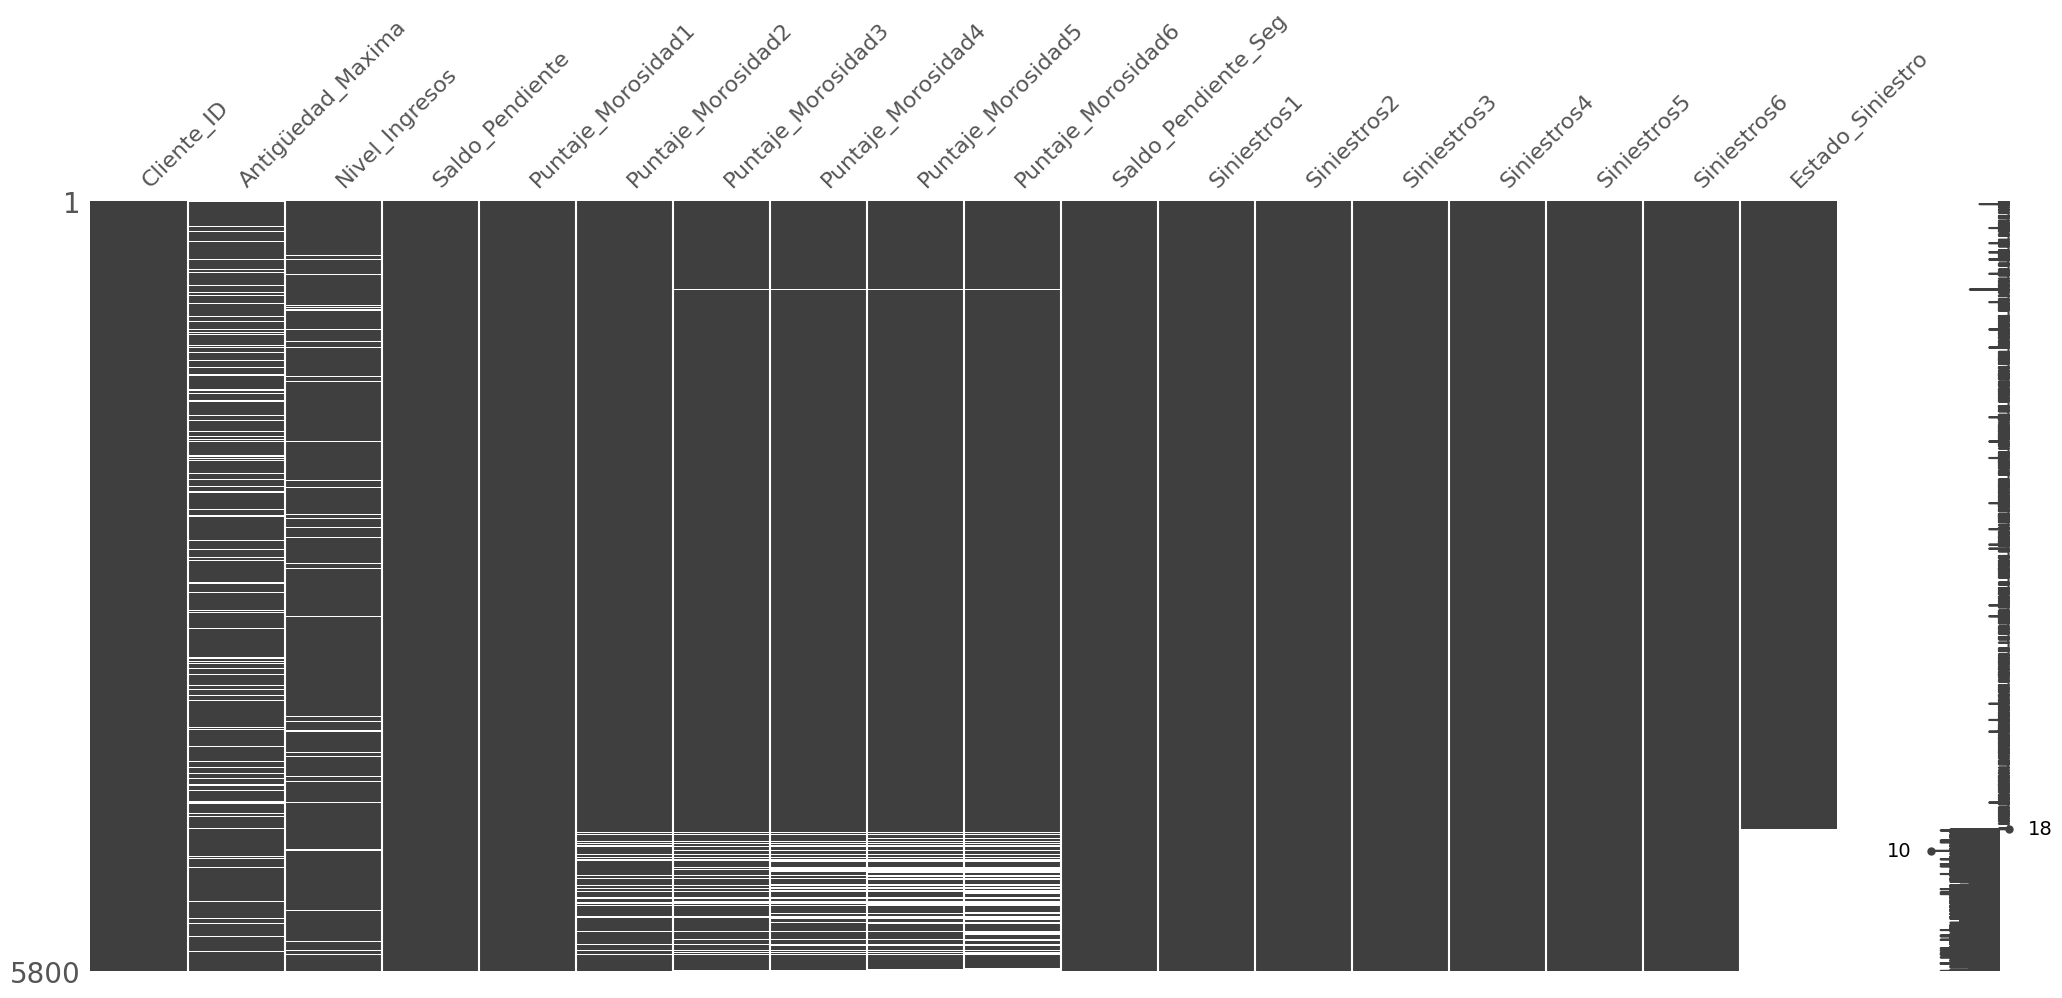

In [59]:
import missingno as msno
msno.matrix(df)

In [60]:
print("Las columnas que tiene el DataFrame (df) son")
df.columns


Las columnas que tiene el DataFrame (df) son


Index(['Cliente_ID', 'Antigüedad_Maxima', 'Nivel_Ingresos', 'Saldo_Pendiente',
       'Puntaje_Morosidad1', 'Puntaje_Morosidad2', 'Puntaje_Morosidad3',
       'Puntaje_Morosidad4', 'Puntaje_Morosidad5', 'Puntaje_Morosidad6',
       'Saldo_Pendiente_Seg', 'Siniestros1', 'Siniestros2', 'Siniestros3',
       'Siniestros4', 'Siniestros5', 'Siniestros6', 'Estado_Siniestro'],
      dtype='object')

Si se suman la cantidad de datos perdidos/nulos por cada campo, es posible ver:

In [61]:
df.isna().sum()

Cliente_ID                0
Antigüedad_Maxima       587
Nivel_Ingresos          273
Saldo_Pendiente           0
Puntaje_Morosidad1        0
Puntaje_Morosidad2      186
Puntaje_Morosidad3      256
Puntaje_Morosidad4      340
Puntaje_Morosidad5      403
Puntaje_Morosidad6      476
Saldo_Pendiente_Seg       0
Siniestros1               0
Siniestros2               0
Siniestros3               0
Siniestros4               0
Siniestros5               0
Siniestros6               0
Estado_Siniestro       1068
dtype: int64

In [62]:
print("La cantidad de registros nulos/perdidos corresponde a:", 
      round(df.isna().sum().sum()/df.size,4)*100, "%")
print("Considerando unicamente al campo con mayor cantidad de registros faltantes, corresponden a ",
       round(df['Estado_Siniestro'].isna().sum().sum()/df.shape[0],4)*100, "%")
print("A partir de lo anterior es que se considera eliminar los registros del vector ",
      "de interés para así no alterar el resultado del modelo.")

La cantidad de registros nulos/perdidos corresponde a: 3.44 %
Considerando unicamente al campo con mayor cantidad de registros faltantes, corresponden a  18.41 %
A partir de lo anterior es que se considera eliminar los registros del vector  de interés para así no alterar el resultado del modelo.


In [63]:
#Generando una copia de la base de datos
df1=df.copy()

#Eliminación de los registros con valores perdidos en la variable target
df1.dropna(subset=["Estado_Siniestro"],axis = 0, inplace = True)
df1.isnull().sum()

Cliente_ID               0
Antigüedad_Maxima      482
Nivel_Ingresos         231
Saldo_Pendiente          0
Puntaje_Morosidad1       0
Puntaje_Morosidad2       0
Puntaje_Morosidad3       1
Puntaje_Morosidad4       3
Puntaje_Morosidad5       4
Puntaje_Morosidad6       4
Saldo_Pendiente_Seg      0
Siniestros1              0
Siniestros2              0
Siniestros3              0
Siniestros4              0
Siniestros5              0
Siniestros6              0
Estado_Siniestro         0
dtype: int64

In [64]:
print("La cantidad total de datos nulos ahora es:", df1.isnull().sum().sum())
print("Es por lo anterior a que la cantidad de registros disminuyó significativamente a un", 
      round(df1.isnull().sum().sum()/df1.size*100,4), "%. Con esto, se procederá a realizar",
      "una imputación de datos usando MUCI.")

La cantidad total de datos nulos ahora es: 725
Es por lo anterior a que la cantidad de registros disminuyó significativamente a un 0.8512 %. Con esto, se procederá a realizar una imputación de datos usando MUCI.


### Transformación de variables e Imputación de datos usando MUCI
#### Transformación de datos
Antes de realizar la imputación de los datos, se procederá a realizar una transformación de la variable cualitativa a cuantitativa transformando los valores "no/si" a "0/1" respectivamente.

In [65]:
#Transformando la variable cualitativa a cuantitativa
df1["Estado_Siniestro"]=df1["Estado_Siniestro"].replace(["no","si"],[0,1])
df1.head(3)

,Cliente_ID,Antigüedad_Maxima,Nivel_Ingresos,Saldo_Pendiente,Puntaje_Morosidad1,Puntaje_Morosidad2,Puntaje_Morosidad3,Puntaje_Morosidad4,Puntaje_Morosidad5,Puntaje_Morosidad6,Saldo_Pendiente_Seg,Siniestros1,Siniestros2,Siniestros3,Siniestros4,Siniestros5,Siniestros6,Estado_Siniestro
0,185,44.0,1.0,604.86,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
1,238,79.0,1.0,1006.21,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
2,346,102.0,1.0,299.23,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0


#### Imputación de datos

In [66]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
columnas = ['Cliente_ID', 'Antigüedad_Maxima', 'Nivel_Ingresos', 'Saldo_Pendiente',
       'Puntaje_Morosidad1', 'Puntaje_Morosidad2', 'Puntaje_Morosidad3',
       'Puntaje_Morosidad4', 'Puntaje_Morosidad5', 'Puntaje_Morosidad6',
       'Saldo_Pendiente_Seg', 'Siniestros1', 'Siniestros2', 'Siniestros3',
       'Siniestros4', 'Siniestros5', 'Siniestros6', 'Estado_Siniestro']

#Crear un imputador iterativo (MICE)

imputer = IterativeImputer(max_iter=10, random_state=0)

columnas_a_transformar = ['Cliente_ID', 'Antigüedad_Maxima', 'Nivel_Ingresos', 'Saldo_Pendiente',
       'Puntaje_Morosidad1', 'Puntaje_Morosidad2', 'Puntaje_Morosidad3',
       'Puntaje_Morosidad4', 'Puntaje_Morosidad5', 'Puntaje_Morosidad6',
       'Saldo_Pendiente_Seg', 'Siniestros1', 'Siniestros2', 'Siniestros3',
       'Siniestros4', 'Siniestros5', 'Siniestros6', 'Estado_Siniestro']

# Seleccionar las columnas relevantes para la imputación
columnas_para_imputar = columnas_a_transformar

# Aplicar la imputación múltiple
df1_imputado = pd.DataFrame(imputer.fit_transform(df1[columnas_para_imputar]), columns=columnas_para_imputar)

# Restaurar las columnas originales no imputadas
df1[columnas_para_imputar] = df1_imputado

df1.head(3)

,Cliente_ID,Antigüedad_Maxima,Nivel_Ingresos,Saldo_Pendiente,Puntaje_Morosidad1,Puntaje_Morosidad2,Puntaje_Morosidad3,Puntaje_Morosidad4,Puntaje_Morosidad5,Puntaje_Morosidad6,Saldo_Pendiente_Seg,Siniestros1,Siniestros2,Siniestros3,Siniestros4,Siniestros5,Siniestros6,Estado_Siniestro
0,185.0,44.0,1.0,604.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,238.0,79.0,1.0,1006.21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,346.0,102.0,1.0,299.23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [67]:
print("Revisando los valores imputados quedan ",df1.isnull().sum().sum(),"elementos perdidos")
df1.isnull().sum()

Revisando los valores imputados quedan  0 elementos perdidos


Cliente_ID             0
Antigüedad_Maxima      0
Nivel_Ingresos         0
Saldo_Pendiente        0
Puntaje_Morosidad1     0
Puntaje_Morosidad2     0
Puntaje_Morosidad3     0
Puntaje_Morosidad4     0
Puntaje_Morosidad5     0
Puntaje_Morosidad6     0
Saldo_Pendiente_Seg    0
Siniestros1            0
Siniestros2            0
Siniestros3            0
Siniestros4            0
Siniestros5            0
Siniestros6            0
Estado_Siniestro       0
dtype: int64

### Registros duplicados

In [68]:
print("Ahora bien, si se verifica la cantidad de registros duplicados:")
print("- No se aprecian datos repetidos para el campo Cliente_ID")
df1[df1["Cliente_ID"].duplicated()].head()


Ahora bien, si se verifica la cantidad de registros duplicados:
- No se aprecian datos repetidos para el campo Cliente_ID


,Cliente_ID,Antigüedad_Maxima,Nivel_Ingresos,Saldo_Pendiente,Puntaje_Morosidad1,Puntaje_Morosidad2,Puntaje_Morosidad3,Puntaje_Morosidad4,Puntaje_Morosidad5,Puntaje_Morosidad6,Saldo_Pendiente_Seg,Siniestros1,Siniestros2,Siniestros3,Siniestros4,Siniestros5,Siniestros6,Estado_Siniestro


### Gráficando variables
#### Gráfico de barras, violín y caja-bigote

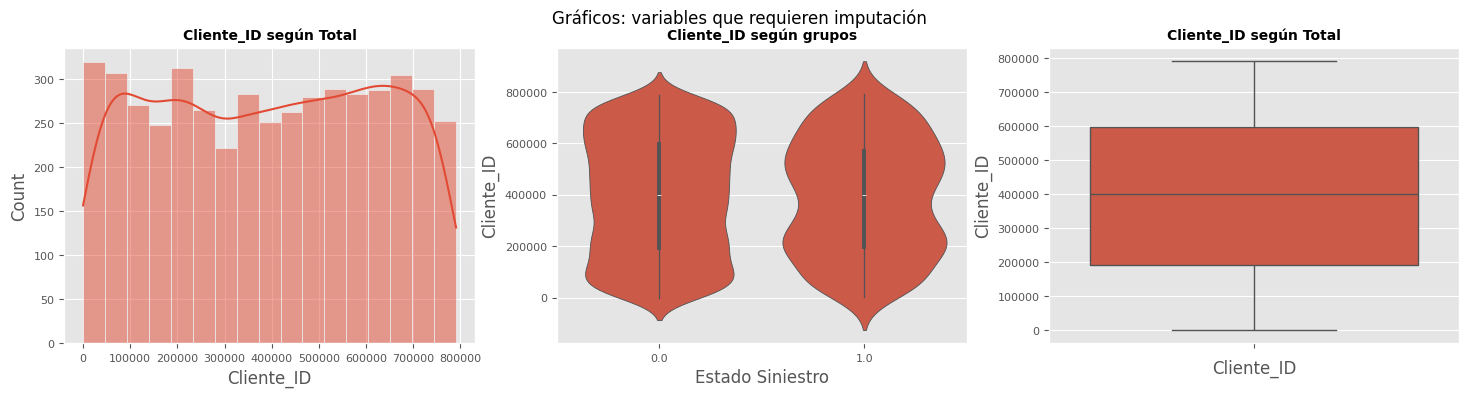

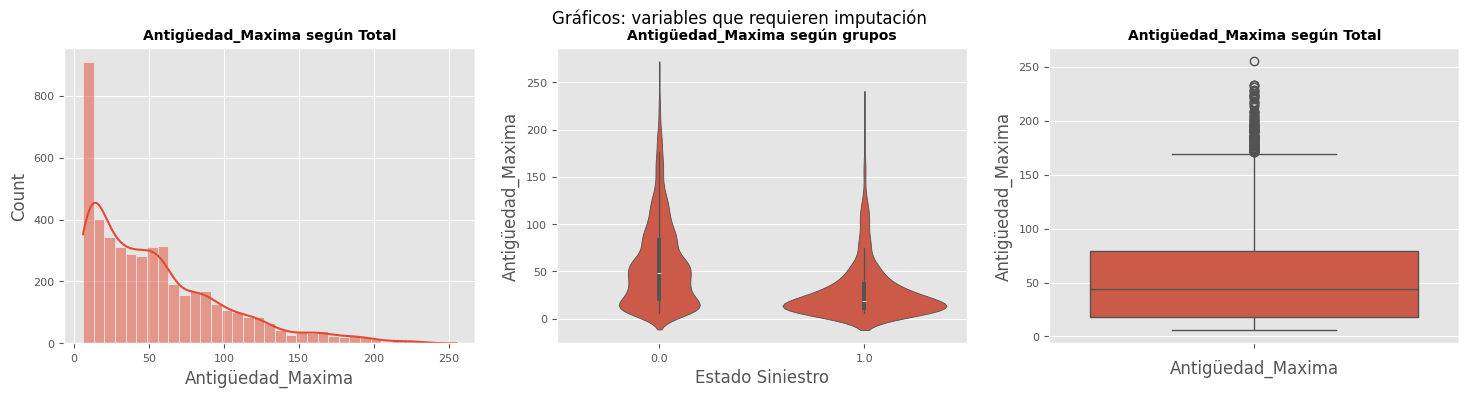

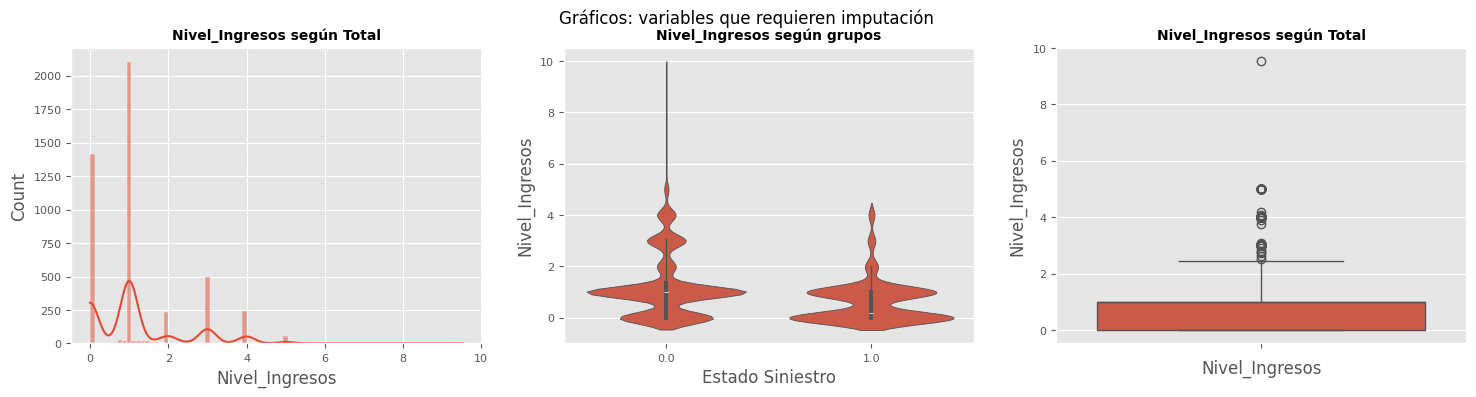

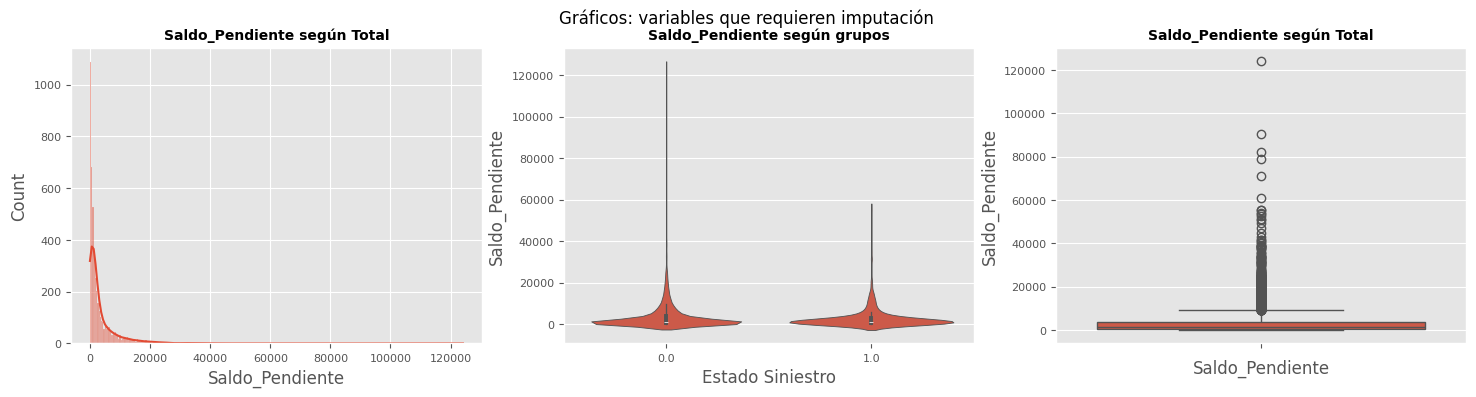

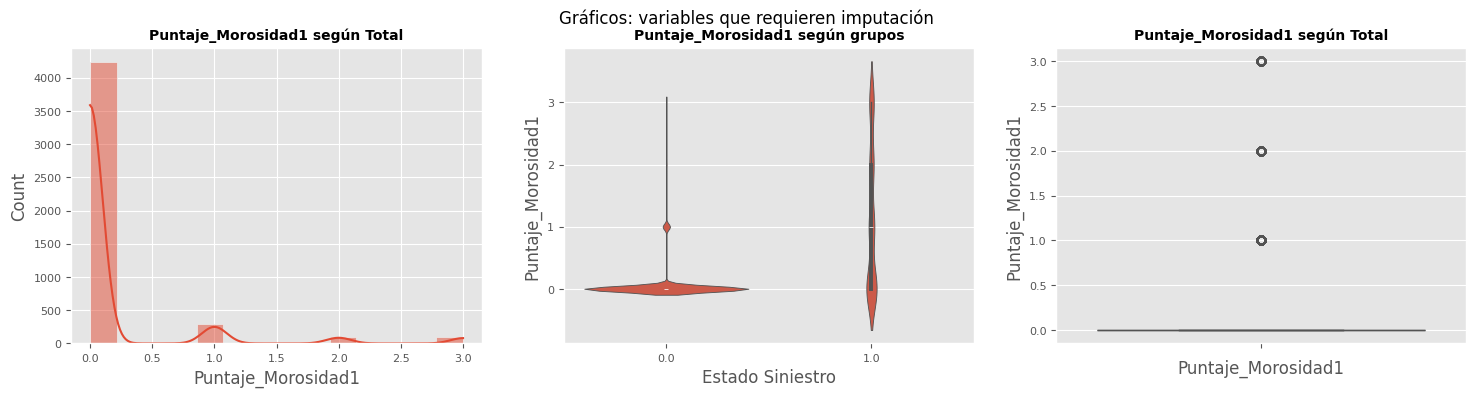

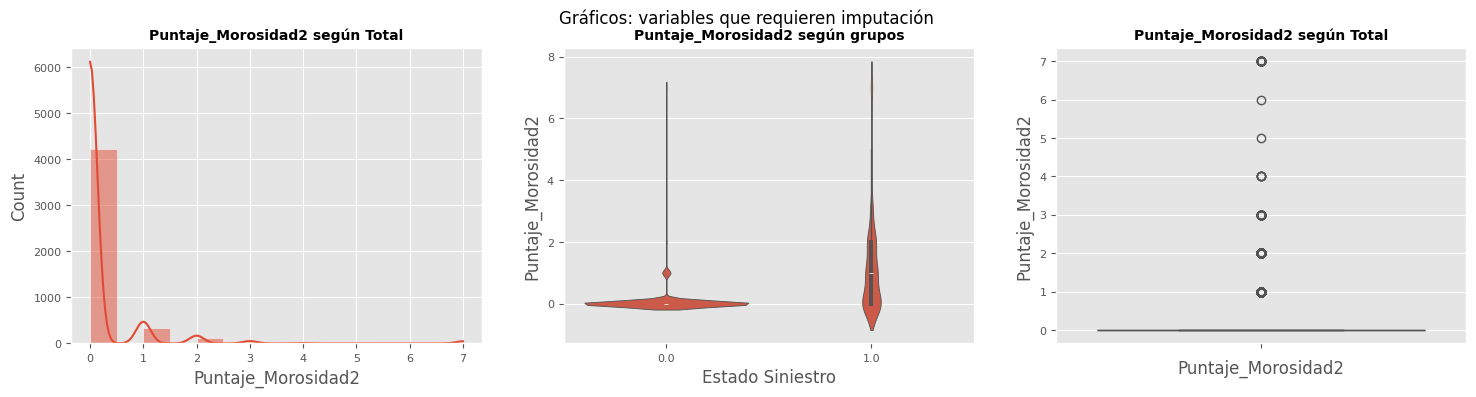

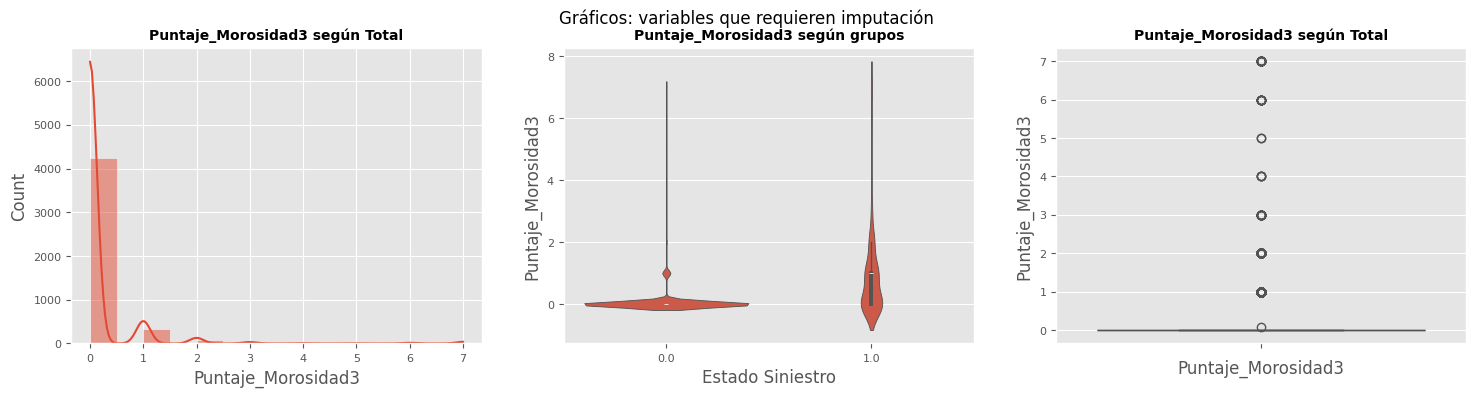

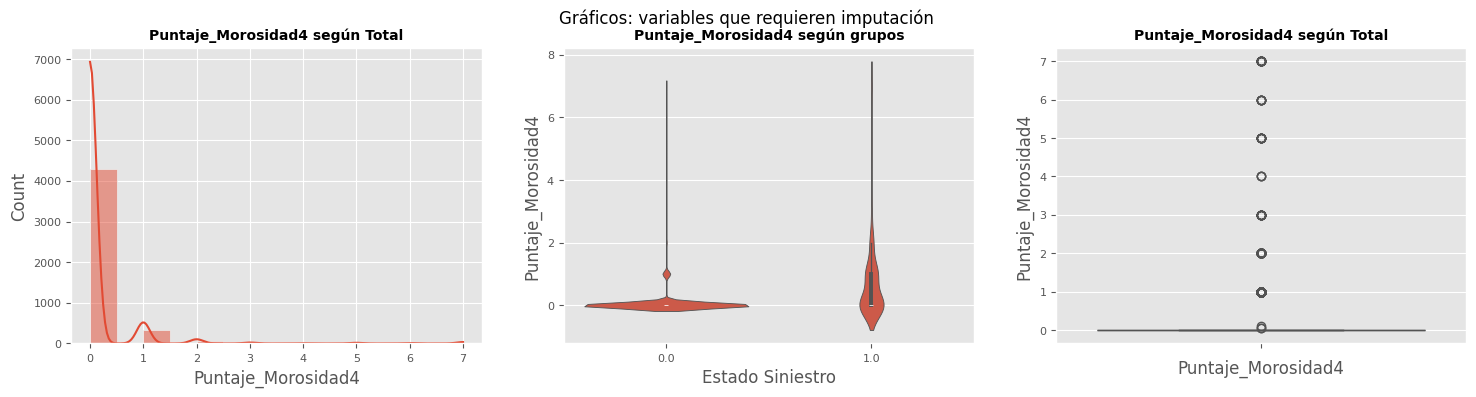

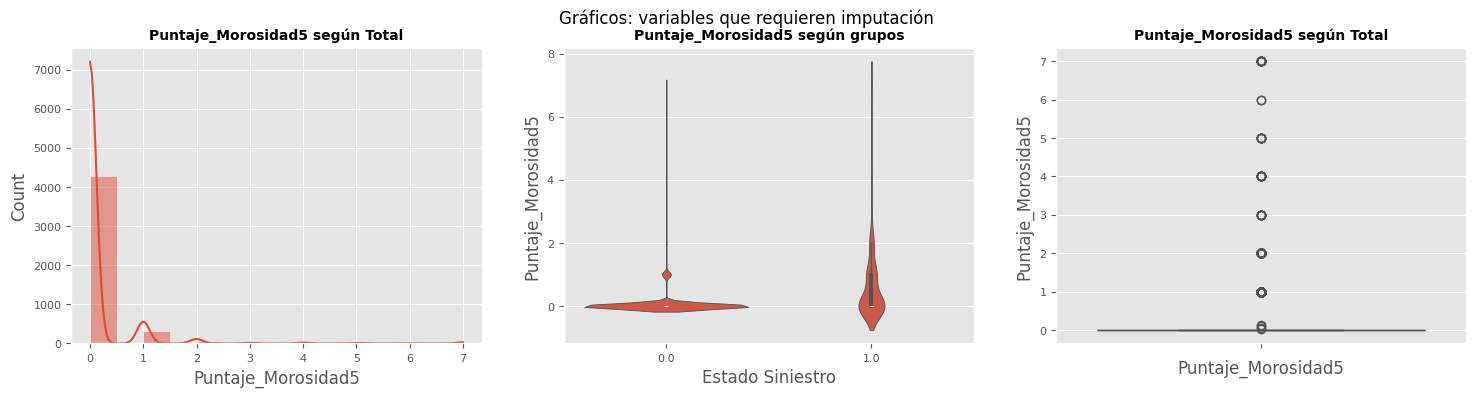

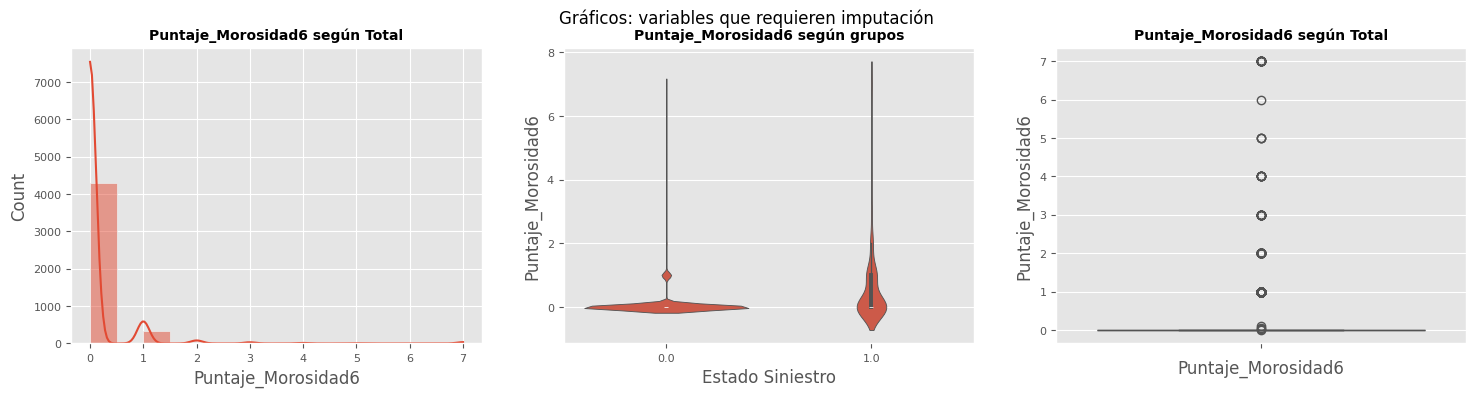

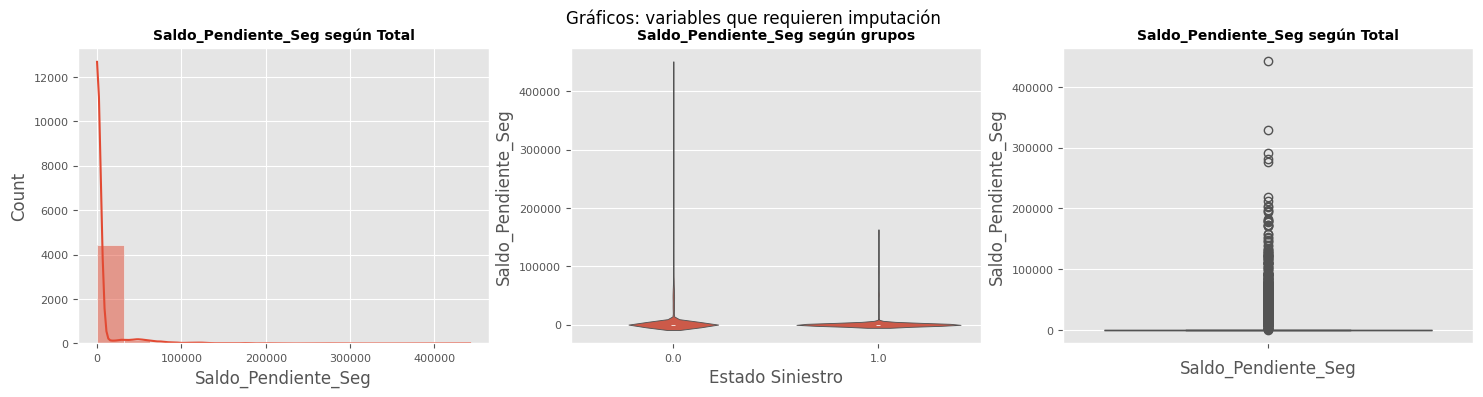

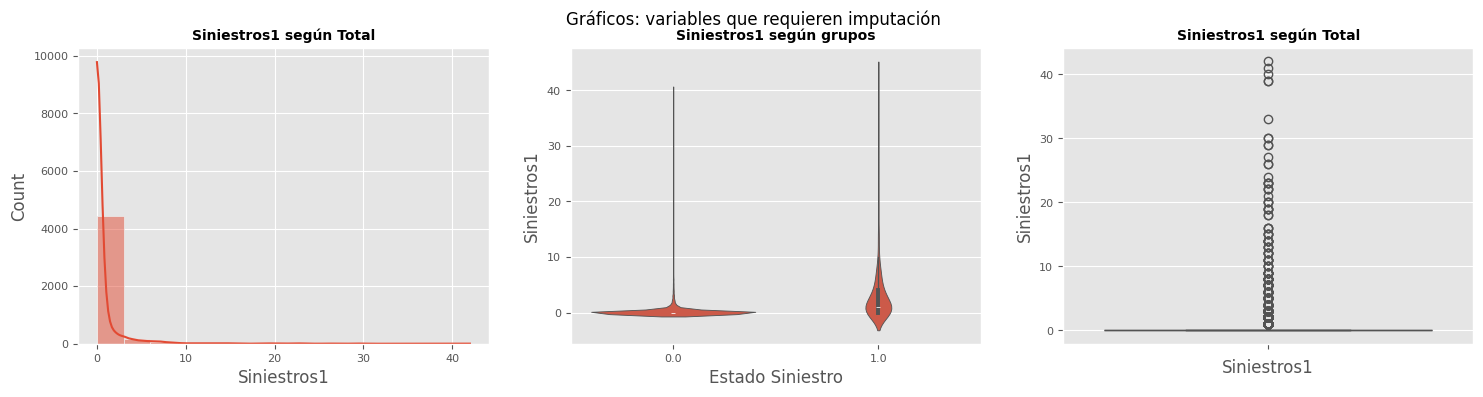

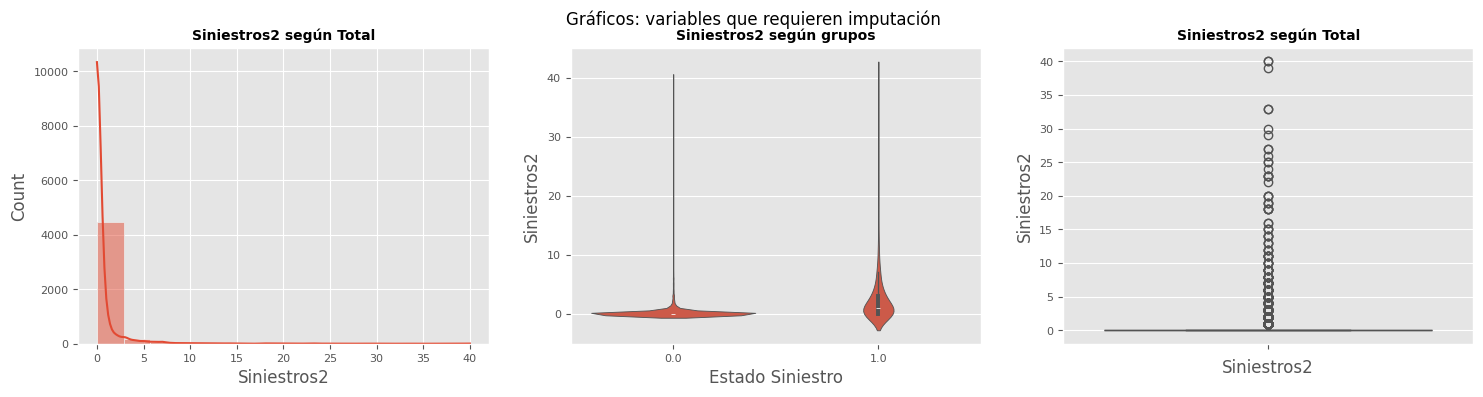

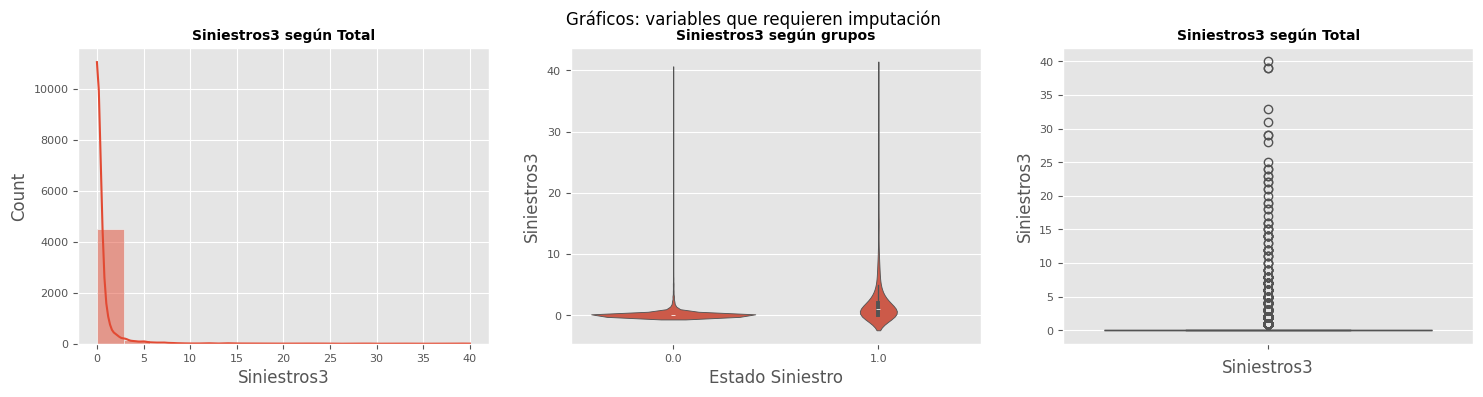

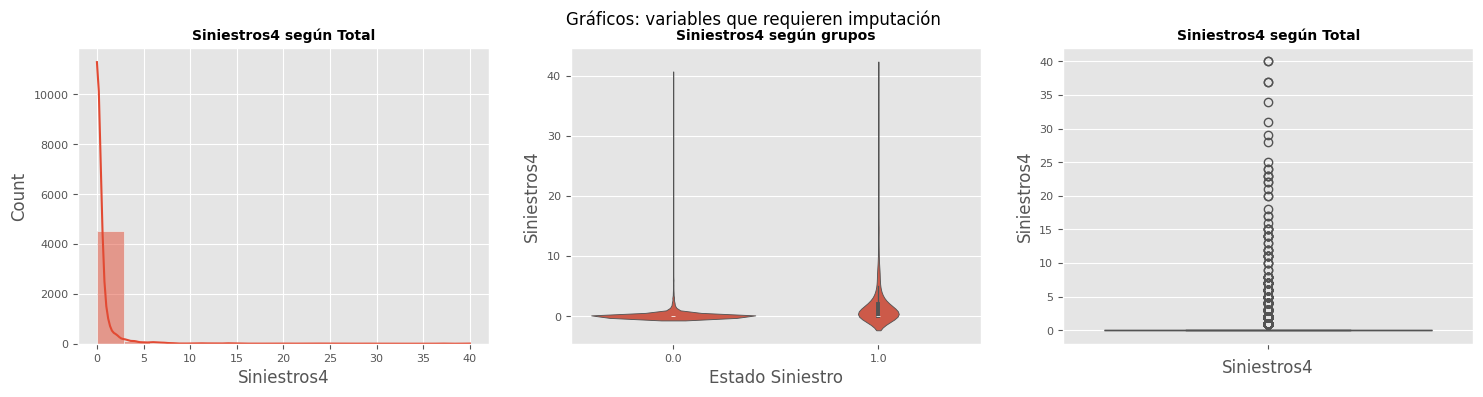

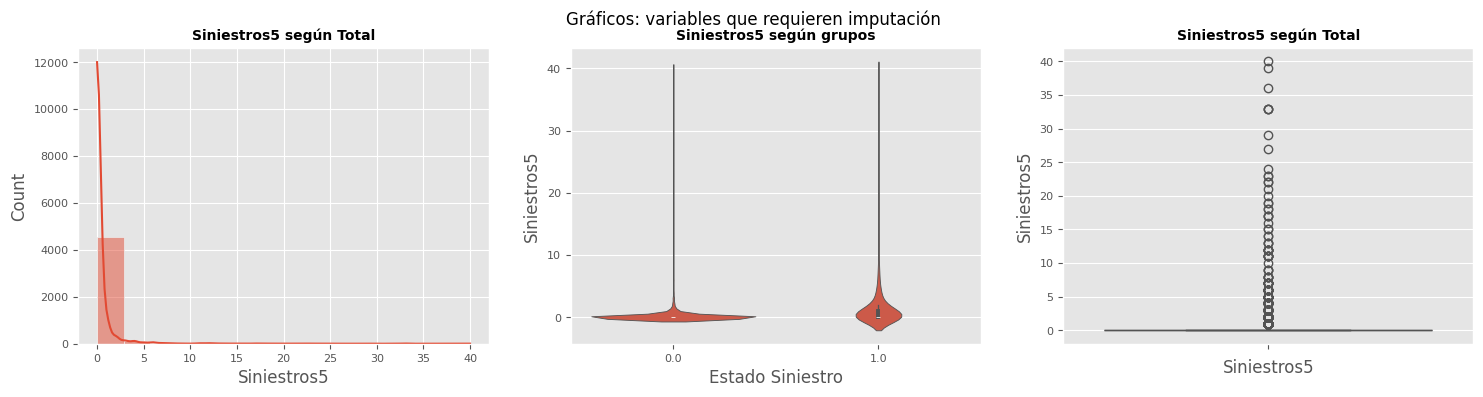

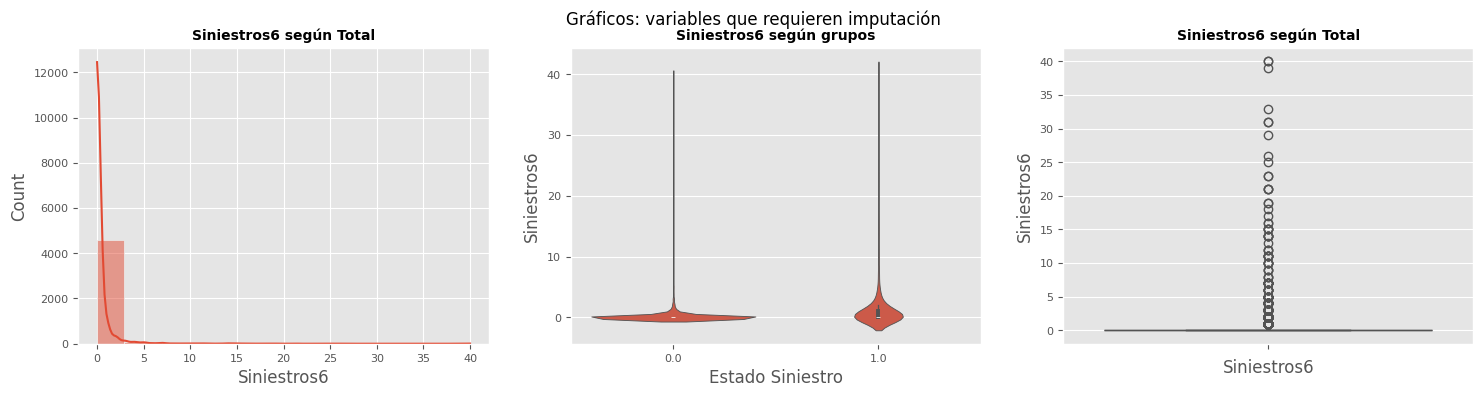

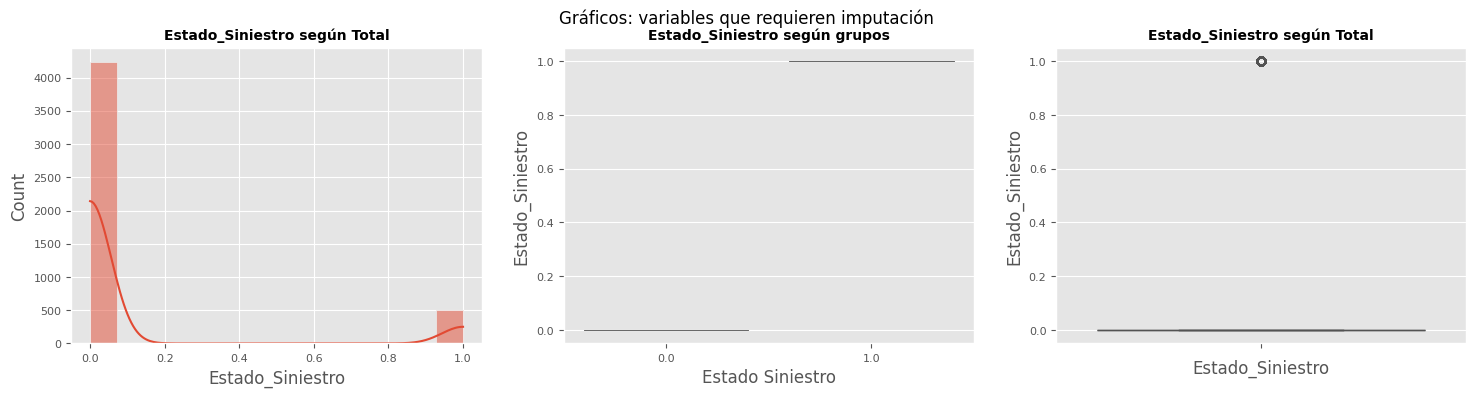

In [69]:
#Graficando las variables
import seaborn as sns
import matplotlib.pyplot as plt
columna = df1.columns #Gráfico de las variables excepto "Estado_Siniestro"
for i, colum in enumerate(columna): 
    fig, ax = plt.subplots(1, 3, figsize=(18, 3.84))
    fig.suptitle('Gráficos: variables que requieren imputación')
    sns.histplot(x=colum, data=df1, kde= True, ax=ax[0])
    ax[0].set_title(str(colum) + " según Total", fontsize = 10, fontweight = "bold")
    ax[0].tick_params(labelsize = 8)
    ax[0].set_xlabel(colum)
    
    sns.violinplot(x = 'Estado_Siniestro', y = colum,  data  = df1, ax=ax[1])
    ax[1].set_title(str(colum) + " según grupos", fontsize = 10, fontweight = "bold")
    ax[1].tick_params(labelsize = 8)
    ax[1].set_xlabel('Estado Siniestro')
    
    sns.boxplot(y = colum,  data  = df1, ax=ax[2])
    ax[2].set_title(str(colum) + " según Total", fontsize = 10, fontweight = "bold")
    ax[2].tick_params(labelsize = 8)
    ax[2].set_xlabel(colum)

### Gráfico de dispersión de datos


'\n'

<Figure size 600x400 with 0 Axes>

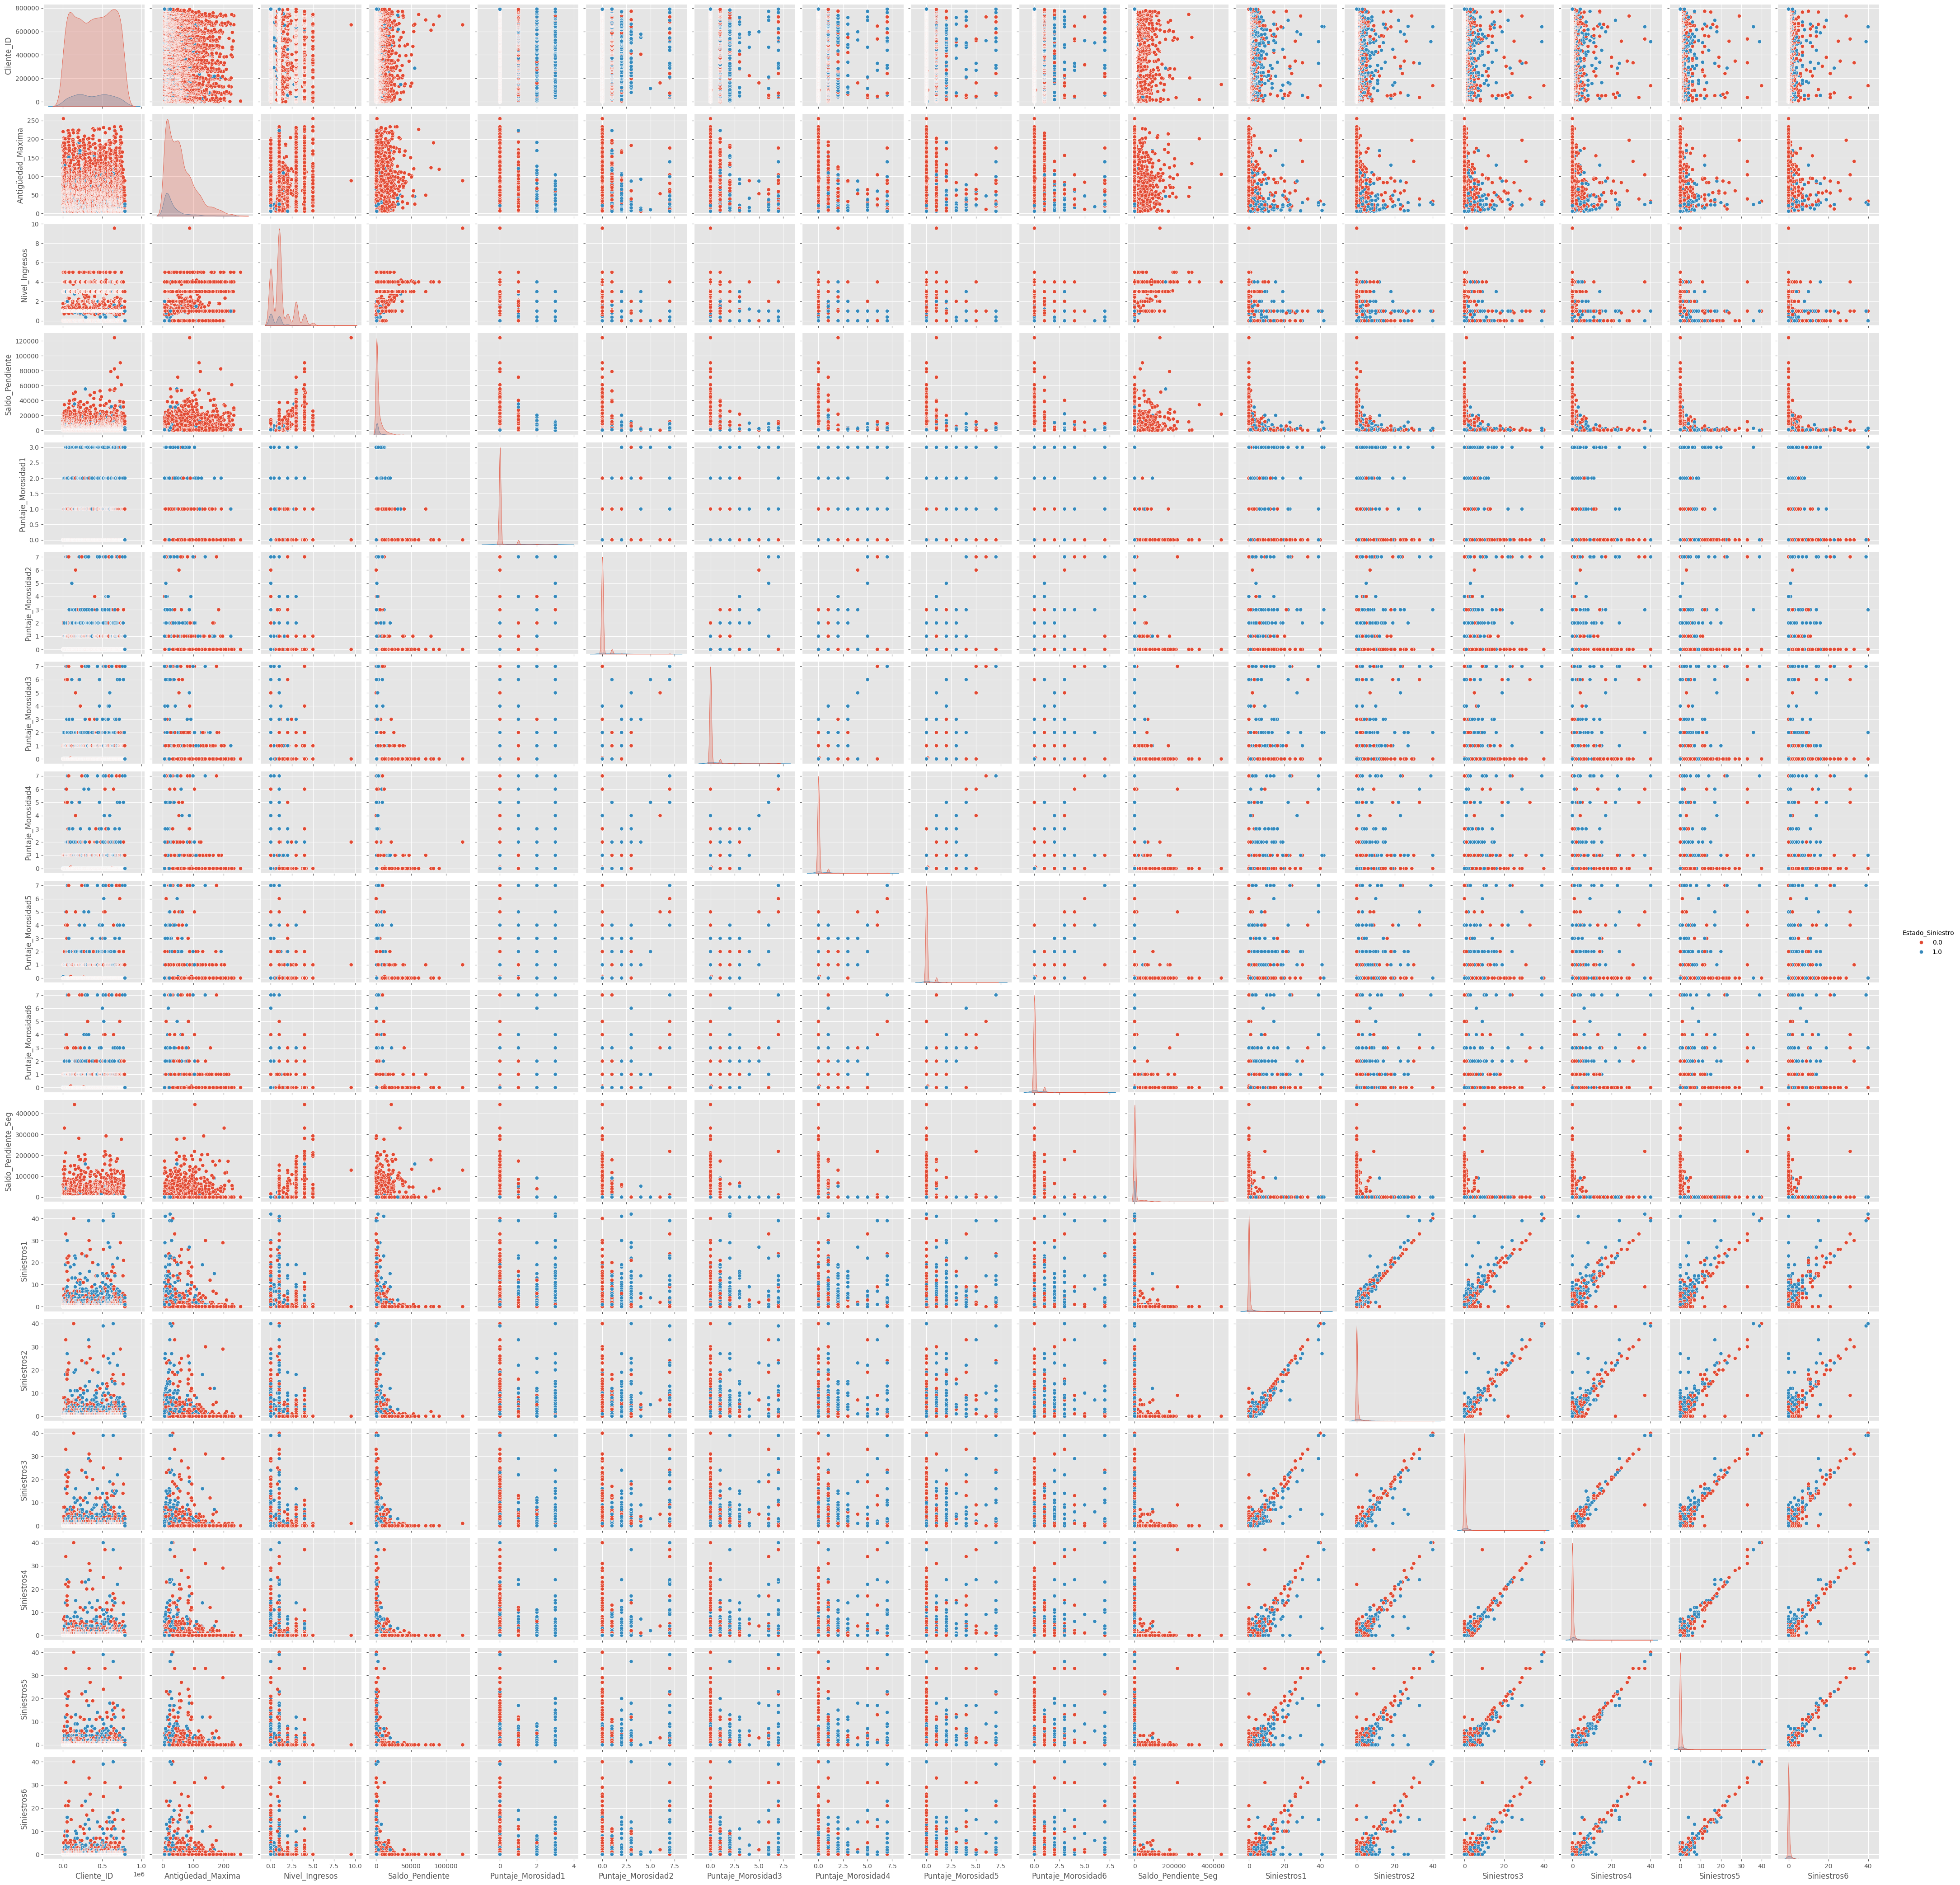

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
"""
En esta sección permite graficar la dispersión de los datos 

plt.figure(figsize=(6,4))
sns.pairplot(data[var_num], diag_kind='kde');

"""

"""
Esta sección permite graficar la dispersión de los datos pero considerando en distintos colores
los grupos. Para este caso, se considera mostrar por color el Estado_Siniestro
"""

plt.figure(figsize=(6, 4))
sns.pairplot(
    df1[columnas_a_transformar],  # Asegúrate de incluir la columna 'Grupos' en el DataFrame
    diag_kind='kde',
    hue='Estado_Siniestro',  # Especifica la columna que define los grupos
    #palette={'A': 'red', 'B': 'blue'}  # Opcional: define colores específicos para los grupos
)

"""
"""

### Gráfico de correlaciones

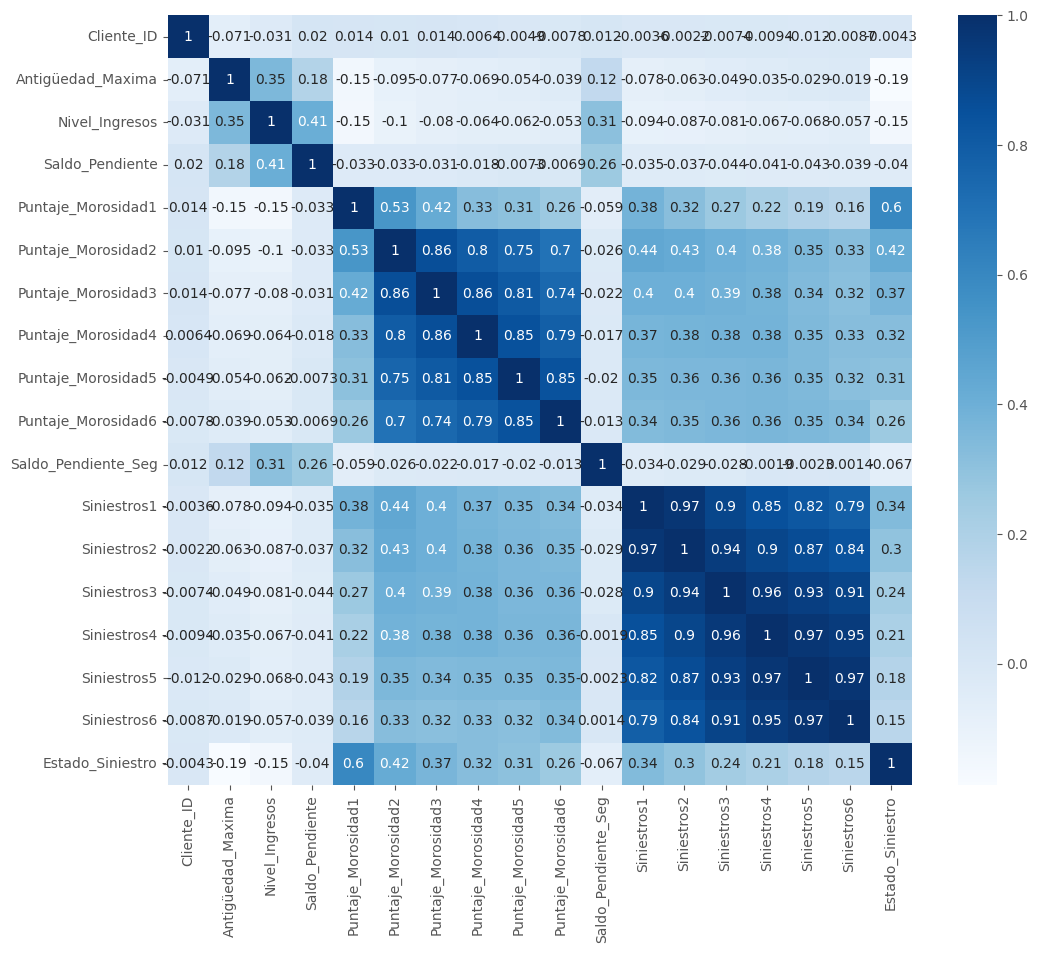

In [71]:
def mapa_calor (x):
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    # Configurar el tamaño de la figura
    plt.figure(figsize=(12, 10))  # Cambia los valores (18, 15) por el tamaño que prefieras
    

    """
    
    """
    sns.heatmap(x,
    xticklabels = x.columns.values,
    yticklabels = x.columns.values,
    annot = True,
    cmap = "Blues" # viridis, Blues
    );

mapa_calor(df1.corr())

### Gráfico de curvas desglozado por variable `Estado_Siniestro`

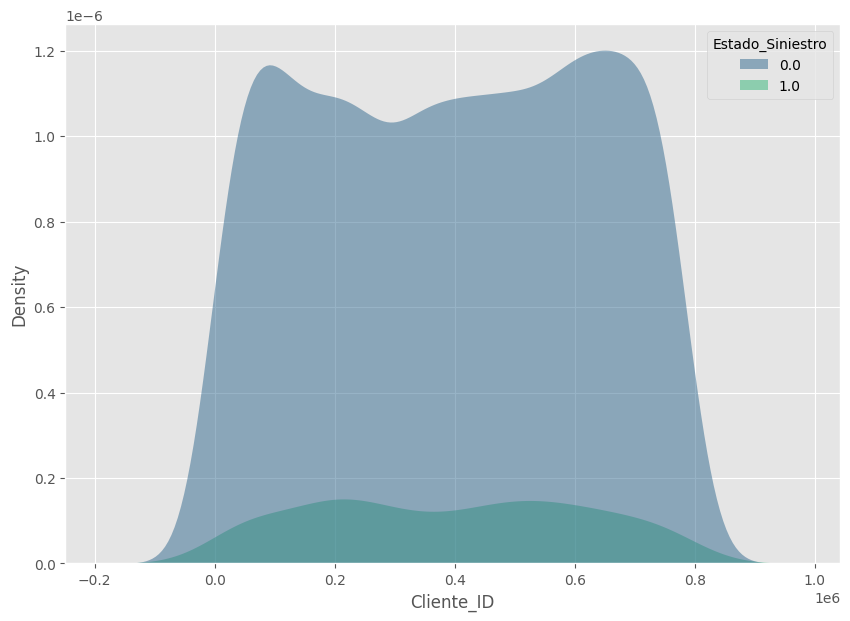

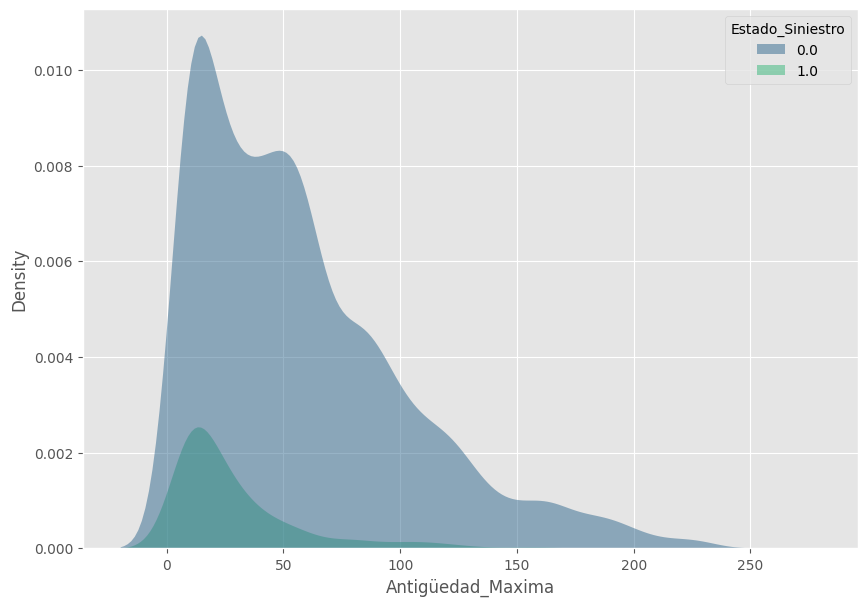

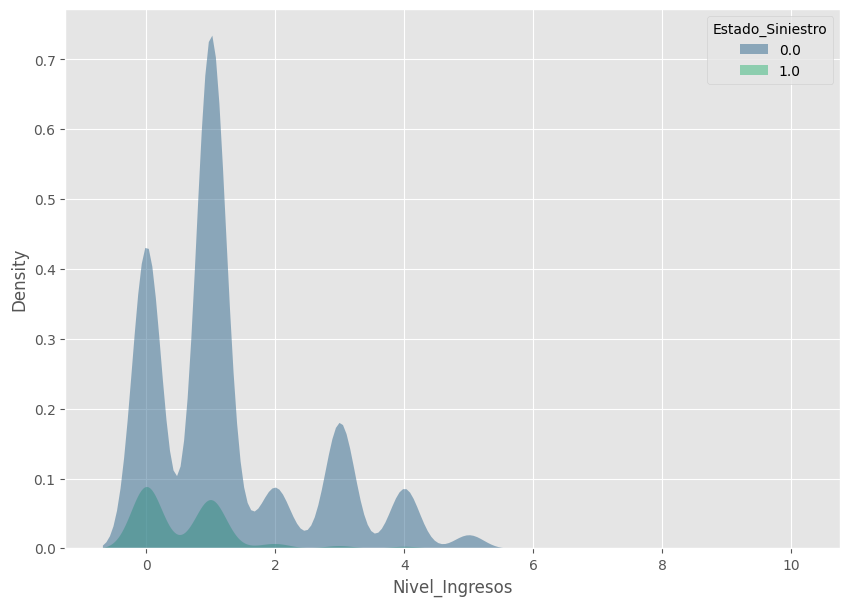

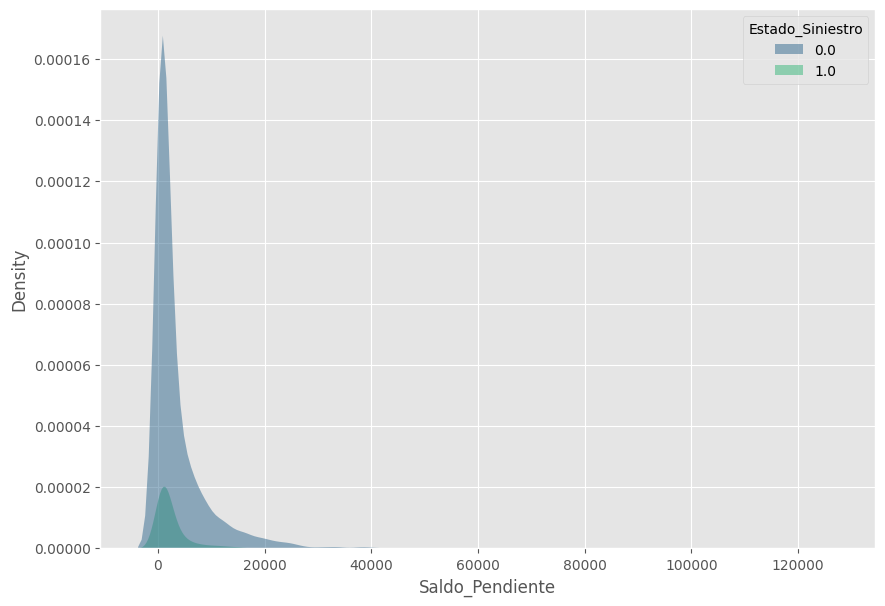

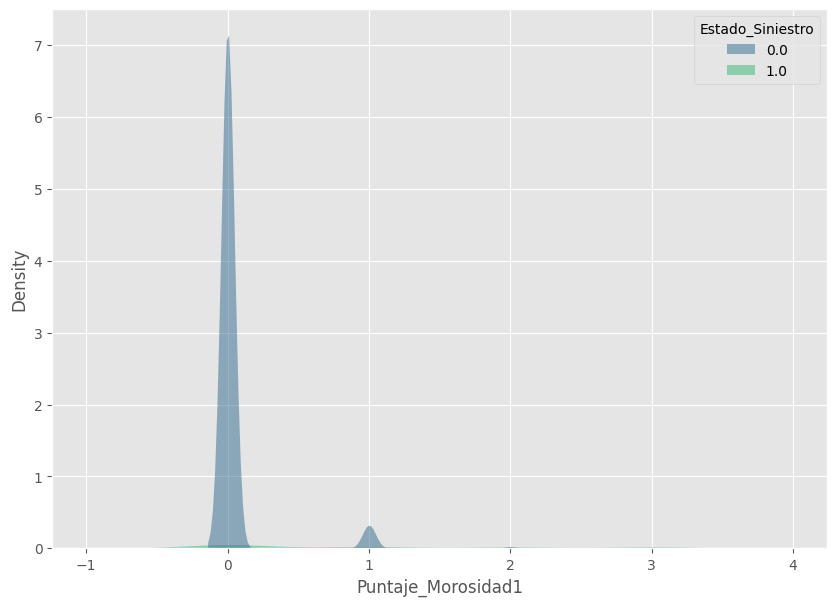

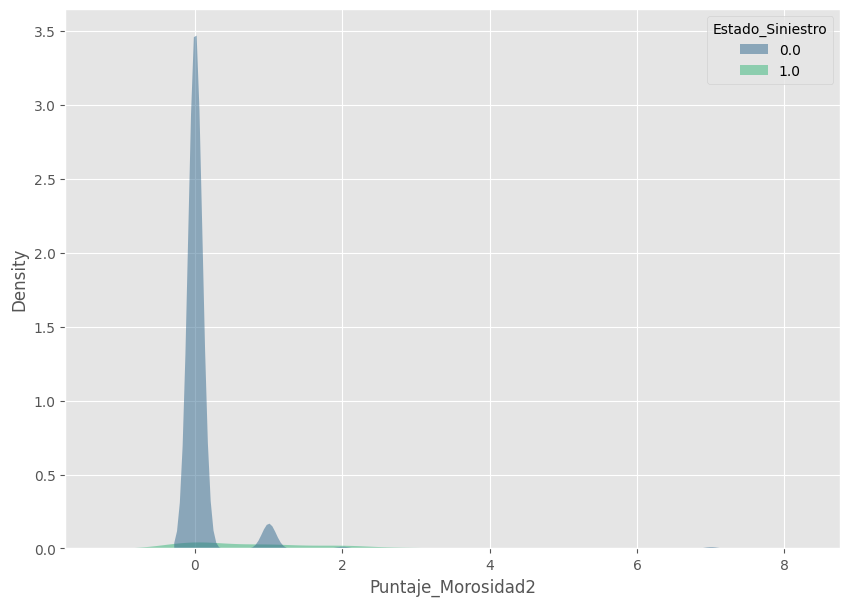

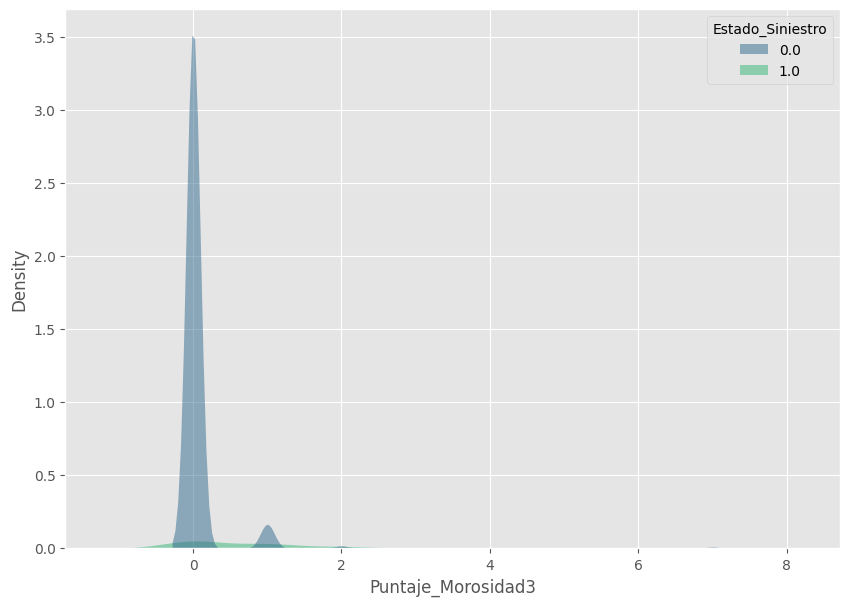

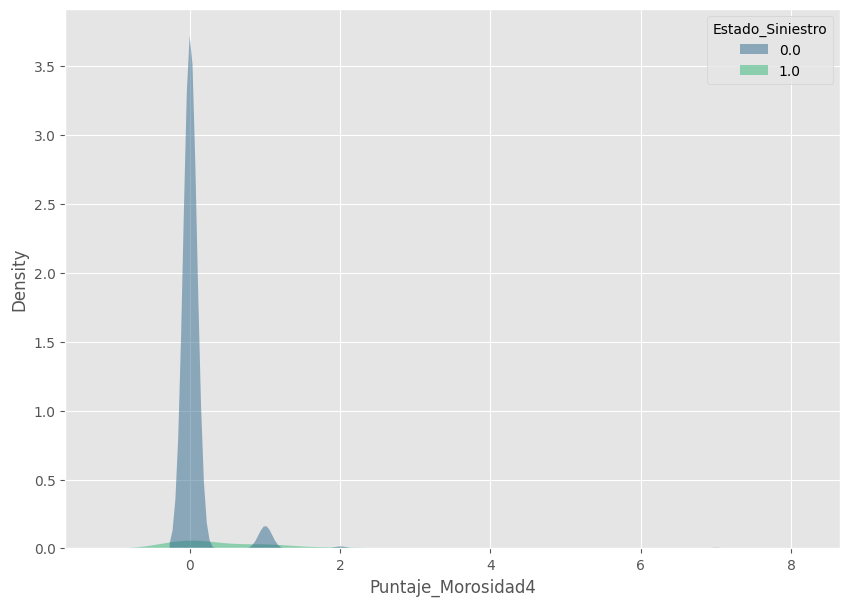

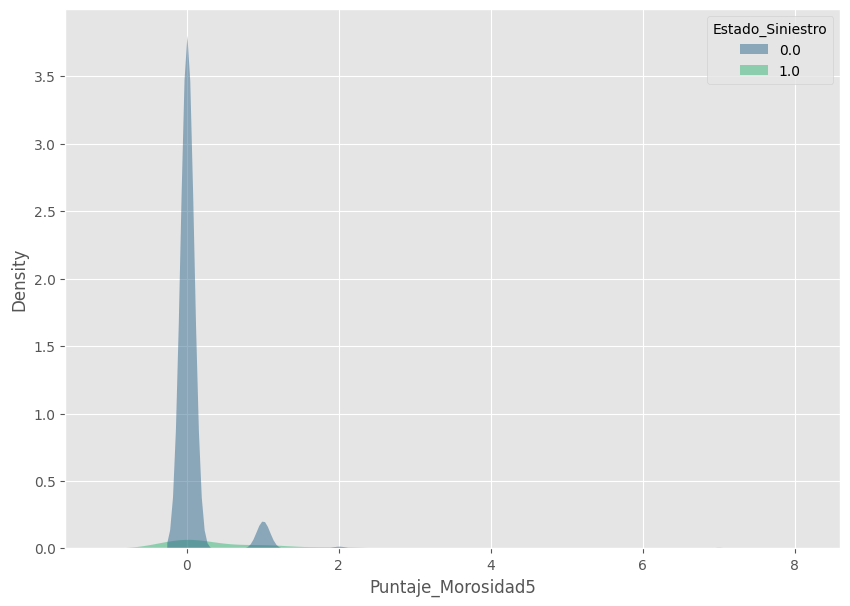

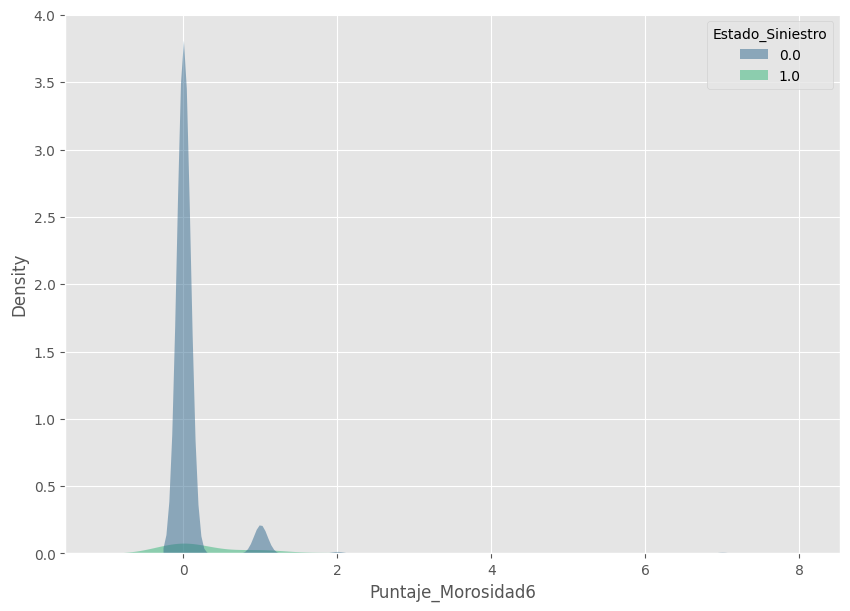

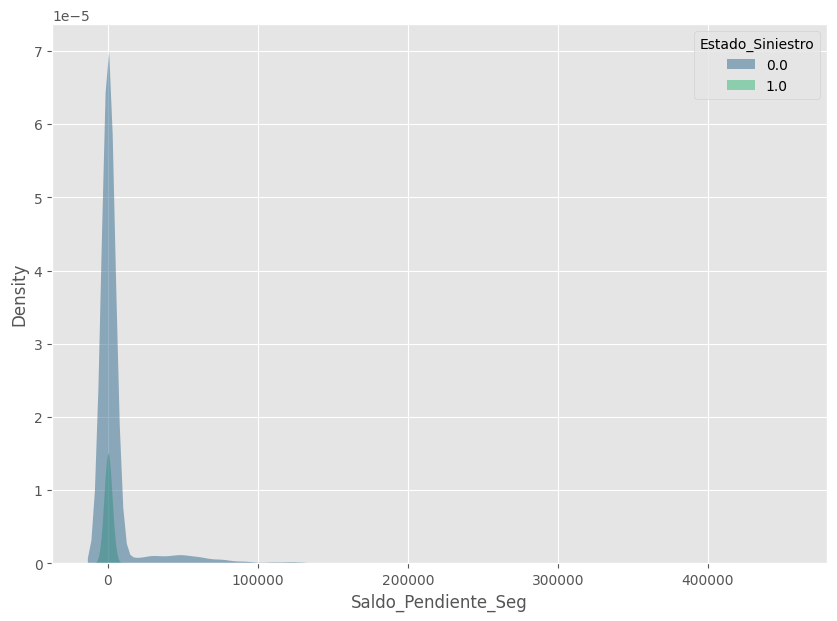

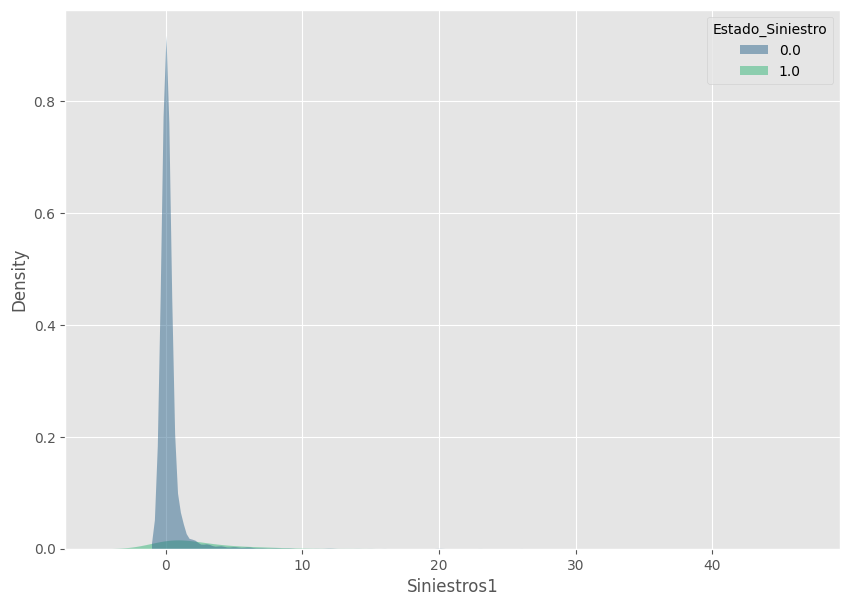

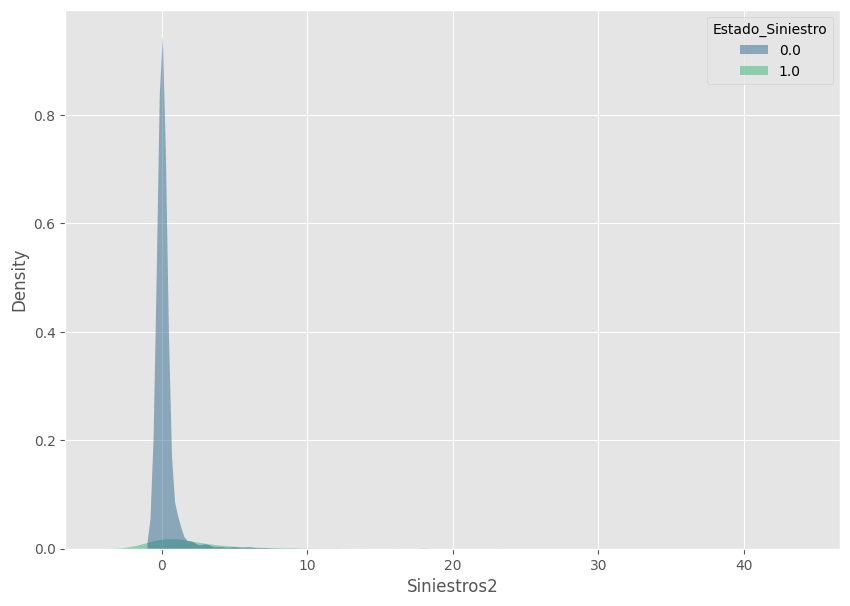

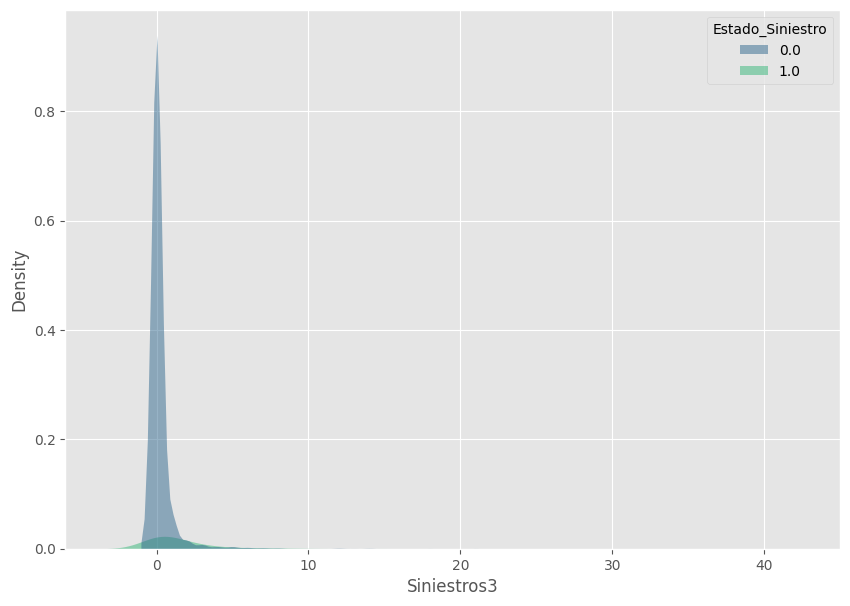

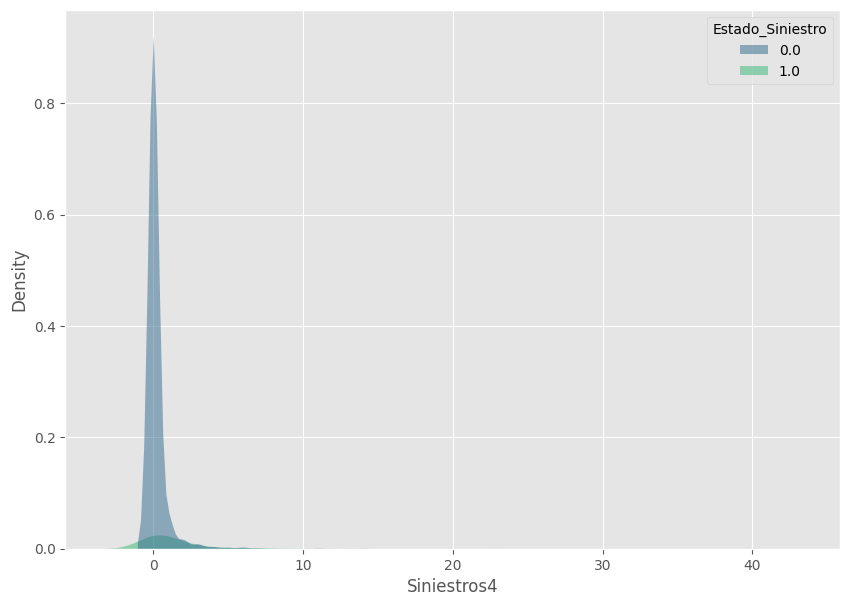

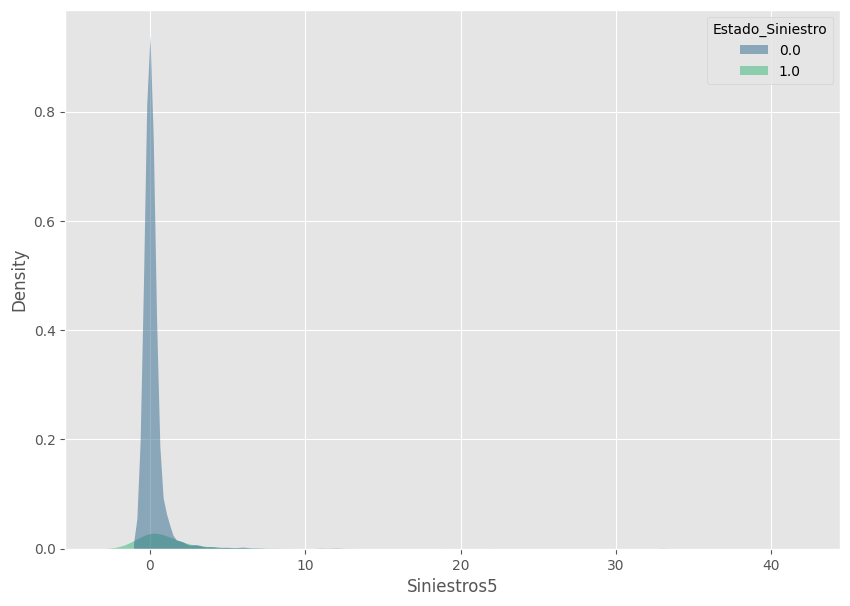

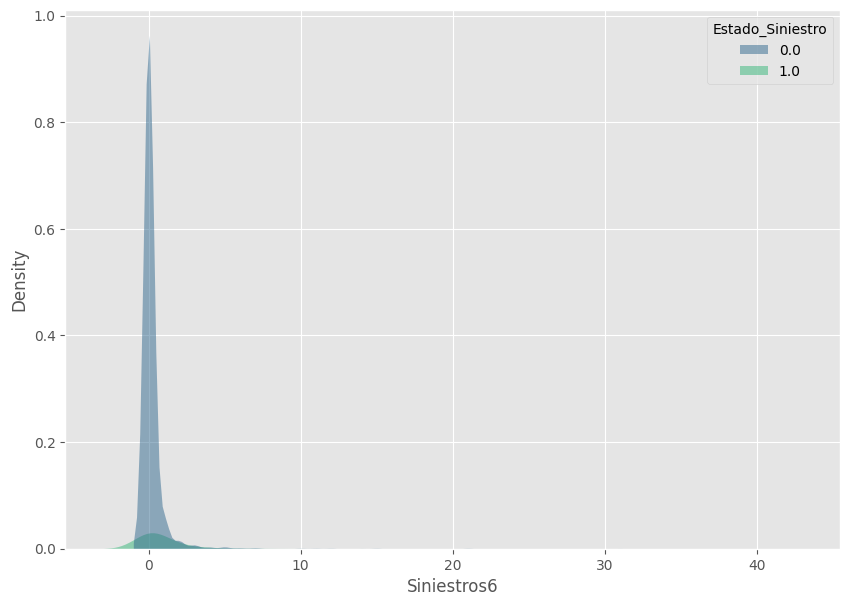

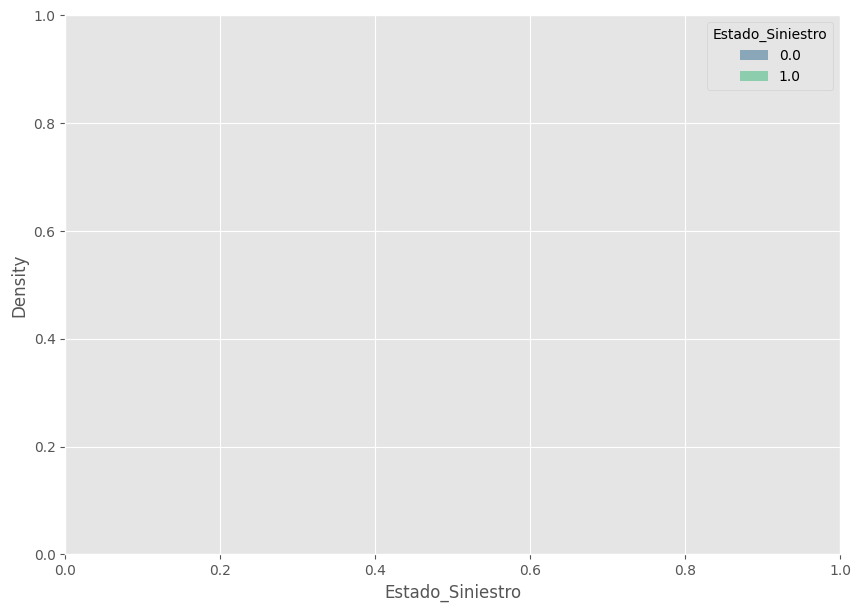

In [72]:
cols_num = df1.columns

for i in cols_num:
    fig, ax = plt.subplots(figsize=(10,7),)
    sns.kdeplot(data=df1, x=i, hue="Estado_Siniestro", fill=True, alpha=.5,
        linewidth=0, palette='viridis') # Paletas de ['flare', 'crest', 'magm
plt.show()

### Curtosis
 La curtosis mide la forma o "grosor" de las colas de una distribución en comparación con una distribución normal. Generalmente, se representan tres tipos principales de curtosis en gráficos: leptocúrtica (colas más pesadas, forma más afilada), mesocúrtica (similar a la distribución normal) y platicúrtica (colas más ligeras, forma más plana).

Curtosis Mesocúrtica: 0.026479272360444117
Curtosis Leptocúrtica: 19.522277024725092
Curtosis Platicúrtica: -1.1799947459219902


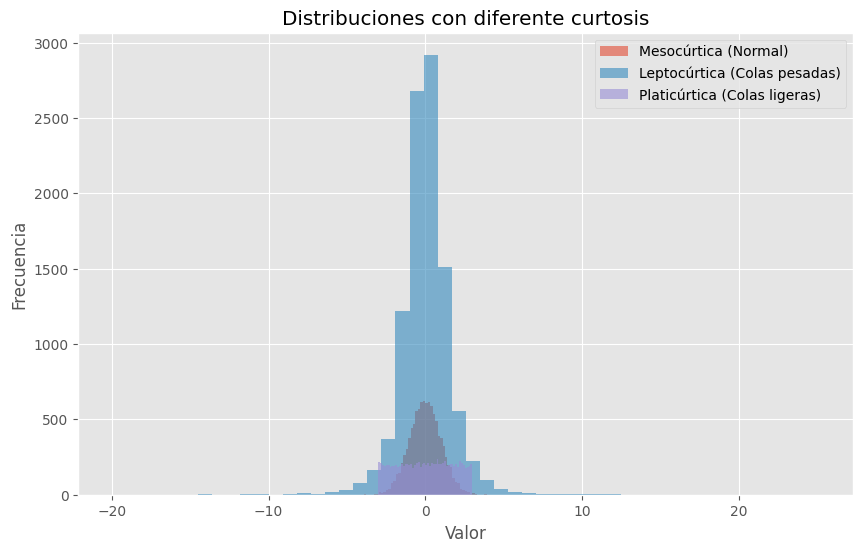

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# Generar datos
np.random.seed(42)
data_mesocurtic = np.random.normal(0, 1, 10000)  # Distribución normal
data_leptocurtic = np.random.standard_t(df=3, size=10000)  # Distribución con colas pesadas
data_platykurtic = np.random.uniform(-3, 3, 10000)  # Distribución más plana

# Calcular curtosis
curtosis_mesocurtic = kurtosis(data_mesocurtic)
curtosis_leptocurtic = kurtosis(data_leptocurtic)
curtosis_platykurtic = kurtosis(data_platykurtic)

print(f"Curtosis Mesocúrtica: {curtosis_mesocurtic}")
print(f"Curtosis Leptocúrtica: {curtosis_leptocurtic}")
print(f"Curtosis Platicúrtica: {curtosis_platykurtic}")

# Graficar distribuciones
plt.figure(figsize=(10, 6))
plt.hist(data_mesocurtic, bins=50, alpha=0.6, label="Mesocúrtica (Normal)")
plt.hist(data_leptocurtic, bins=50, alpha=0.6, label="Leptocúrtica (Colas pesadas)")
plt.hist(data_platykurtic, bins=50, alpha=0.6, label="Platicúrtica (Colas ligeras)")
plt.legend()
plt.title("Distribuciones con diferente curtosis")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

In [74]:
var_num = df1.select_dtypes(include=['float64', 'int']).columns
from scipy.stats import kurtosis
def kurtosis_data(x):
    curtosis = kurtosis(x, fisher=True)
    
    if curtosis >0:
        return ('Es Leptocúrtica-->', round(curtosis,2 ))
    elif curtosis ==0: # 0.03
        return ('Es Mesocúrtica-->', round(curtosis,2 ))
    else:
        return ('Es Platicúrtica-->', round(curtosis,2 ))

df1[var_num].apply(kurtosis_data, axis=0).T

,0,1
Cliente_ID,Es Platicúrtica-->,-1.24
Antigüedad_Maxima,Es Leptocúrtica-->,1.28
Nivel_Ingresos,Es Leptocúrtica-->,1.29
Saldo_Pendiente,Es Leptocúrtica-->,51.84
Puntaje_Morosidad1,Es Leptocúrtica-->,14.31
Puntaje_Morosidad2,Es Leptocúrtica-->,47.9
Puntaje_Morosidad3,Es Leptocúrtica-->,53.82
Puntaje_Morosidad4,Es Leptocúrtica-->,60.56
Puntaje_Morosidad5,Es Leptocúrtica-->,61.1
Puntaje_Morosidad6,Es Leptocúrtica-->,70.63


### Métricas estadísticas

In [75]:
round(df1.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
Cliente_ID,4732.0,393450.75,231501.02,185.00,192643.75,399771.50,596389.25,790771.00
Antigüedad_Maxima,4732.0,55.07,45.30,6.00,18.00,44.00,79.00,255.00
Nivel_Ingresos,4732.0,1.17,1.19,0.00,0.00,1.00,1.00,9.54
Saldo_Pendiente,4732.0,3660.04,6559.26,0.01,465.09,1299.42,3910.11,124102.08
Puntaje_Morosidad1,4732.0,0.17,0.55,0.00,0.00,0.00,0.00,3.00
Puntaje_Morosidad2,4732.0,0.19,0.75,0.00,0.00,0.00,0.00,7.00
Puntaje_Morosidad3,4732.0,0.18,0.71,0.00,0.00,0.00,0.00,7.00
Puntaje_Morosidad4,4732.0,0.16,0.67,0.00,0.00,0.00,0.00,7.00
Puntaje_Morosidad5,4732.0,0.15,0.64,0.00,0.00,0.00,0.00,7.00
Puntaje_Morosidad6,4732.0,0.14,0.62,0.00,0.00,0.00,0.00,7.00


### Coeficientes de variación

In [76]:
def coeficiente_variacion(x):
    import numpy as np
    import statistics as stats
    m = stats.mean(x)
    sd = np.std(x)
    return sd/m*100

var_numerica = df1.columns
#var_numerica = var_numerica[1:]
df1[var_numerica].apply(coeficiente_variacion, axis=0).round(2)

Cliente_ID              58.83
Antigüedad_Maxima       82.24
Nivel_Ingresos         101.24
Saldo_Pendiente        179.19
Puntaje_Morosidad1     332.04
Puntaje_Morosidad2     384.12
Puntaje_Morosidad3     407.37
Puntaje_Morosidad4     430.88
Puntaje_Morosidad5     418.28
Puntaje_Morosidad6     431.69
Saldo_Pendiente_Seg    419.70
Siniestros1            420.69
Siniestros2            440.76
Siniestros3            461.09
Siniestros4            487.70
Siniestros5            508.88
Siniestros6            539.36
Estado_Siniestro       292.24
dtype: float64

### Conclusiones de análisis exploratorio de datos
...
...

## Análisis de componentes principales (PCA)
El Análisis de Componentes Principales (PCA) es una técnica estadística utilizada para reducir la dimensionalidad de un conjunto de datos mientras se conserva la mayor cantidad posible de información relevante. Es especialmente útil cuando se trabaja con datos que tienen muchas variables correlacionadas entre sí.
¿Cómo funciona PCA?
- Transformación de datos: PCA convierte las variables originales en nuevas variables llamadas componentes principales, que son combinaciones lineales de las variables originales.
- Orden de importancia: Las componentes principales se ordenan según la cantidad de varianza que explican en los datos. La primera componente principal explica la mayor parte de la variabilidad, la segunda explica la mayor parte de lo que queda, y así sucesivamente.
- Reducción de dimensionalidad: Se seleccionan las primeras componentes principales que explican la mayor parte de la varianza, descartando las demás para simplificar el análisis.

Aplicaciones comunes:
- Visualización de datos: Representar datos en 2D o 3D para facilitar su interpretación.
- Preprocesamiento: Reducir el número de variables antes de aplicar modelos de aprendizaje automático.
- Detección de patrones: Identificar relaciones subyacentes entre variables.  

¿Cómo se realiza el PCA paso a paso?
- Estandarización de los datos:
Dado que PCA depende de la varianza de las variables, es importante escalar los datos para que todas las variables tengan una magnitud comparable. Esto se logra normalmente mediante la estandarización (restar la media y dividir entre la desviación estándar).
- Cálculo de la matriz de covarianza o correlación:
Una vez estandarizados los datos, se calcula la matriz de covarianza (o correlación) para identificar cómo las variables están relacionadas entre sí.
- Obtención de los valores propios (eigenvalues) y vectores propios (eigenvectors):
Los valores propios determinan la cantidad de varianza explicada por cada componente principal. Los vectores propios representan la dirección de las nuevas componentes en el espacio de las variables originales.
- Selección de componentes principales:
Se ordenan los componentes principales según la cantidad de varianza explicada (mayor a menor). Usualmente, se seleccionan aquellos que acumulan un porcentaje alto de la varianza total, por ejemplo, el 80% o 90%.
- Proyección de los datos:
Los datos originales se transforman al nuevo espacio definido por las componentes principales, reduciendo así la dimensionalidad mientras se conserva la información esencial.






In [77]:
#Recodificando la variable objetivo
df2 = df1.copy()
#Transformando la variable cualitativa a cuantitativa
df2["Estado_Siniestro"]=df2["Estado_Siniestro"].replace([0,1],["no","si"])
df2.head(3)

,Cliente_ID,Antigüedad_Maxima,Nivel_Ingresos,Saldo_Pendiente,Puntaje_Morosidad1,Puntaje_Morosidad2,Puntaje_Morosidad3,Puntaje_Morosidad4,Puntaje_Morosidad5,Puntaje_Morosidad6,Saldo_Pendiente_Seg,Siniestros1,Siniestros2,Siniestros3,Siniestros4,Siniestros5,Siniestros6,Estado_Siniestro
0,185.0,44.0,1.0,604.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no
1,238.0,79.0,1.0,1006.21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no
2,346.0,102.0,1.0,299.23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no


La variable `Cliente_ID` no se considerará dentro de los análisis estadísticos debido a que no representará información asociativa referencial que permita describir los datos.

In [78]:
#Data con variables numéricas
df3 = df2.iloc[:,0:17]
columns = df3.select_dtypes(exclude=['object']).columns # columnas numérica solamente
columns

Index(['Cliente_ID', 'Antigüedad_Maxima', 'Nivel_Ingresos', 'Saldo_Pendiente',
       'Puntaje_Morosidad1', 'Puntaje_Morosidad2', 'Puntaje_Morosidad3',
       'Puntaje_Morosidad4', 'Puntaje_Morosidad5', 'Puntaje_Morosidad6',
       'Saldo_Pendiente_Seg', 'Siniestros1', 'Siniestros2', 'Siniestros3',
       'Siniestros4', 'Siniestros5', 'Siniestros6'],
      dtype='object')

In [79]:
#Importando librería
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

In [80]:
# Entrenamiento modelo PCA con escalado de los datos
from sklearn.datasets import make_blobs
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(df3)
# Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']
modelo_pca.components_.round(3) # matriz i * j


array([[-0.001, -0.036, -0.048, -0.022,  0.163,  0.27 ,  0.268,  0.264,
         0.258,  0.25 , -0.015,  0.32 ,  0.328,  0.331,  0.328,  0.32 ,
         0.31 ],
       [ 0.013, -0.049, -0.034, -0.004,  0.154,  0.332,  0.356,  0.355,
         0.356,  0.328, -0.021, -0.21 , -0.231, -0.251, -0.257, -0.269,
        -0.276],
       [-0.042,  0.424,  0.583,  0.504, -0.129,  0.008,  0.036,  0.06 ,
         0.07 ,  0.079,  0.436, -0.022, -0.008,  0.003,  0.024,  0.025,
         0.031],
       [ 0.803, -0.35 , -0.001,  0.245,  0.269,  0.048, -0.003, -0.052,
        -0.082, -0.103,  0.263,  0.064,  0.038, -0.001, -0.021, -0.036,
        -0.04 ],
       [-0.533, -0.229,  0.014,  0.224,  0.659,  0.125, -0.011, -0.122,
        -0.156, -0.198,  0.19 ,  0.141,  0.073, -0.008, -0.063, -0.089,
        -0.108],
       [-0.238, -0.574, -0.112, -0.089, -0.404, -0.086, -0.011,  0.068,
         0.086,  0.111,  0.613, -0.093, -0.056, -0.007,  0.044,  0.062,
         0.069],
       [-0.106, -0.44 ,  0.085,  0

In [81]:
# Se combierte el array a dataframe para añadir nombres a los ejes.
componentes = pd.DataFrame(
data = modelo_pca.components_,
columns = df3.columns,
index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 
         'PC9','PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15','PC16','PC17'])
componentes = componentes.transpose().round(3)
componentes

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17
Cliente_ID,-0.001,0.013,-0.042,0.803,-0.533,-0.238,-0.106,0.019,0.020,0.008,-0.000,0.005,-0.004,0.001,0.003,-0.002,0.002
Antigüedad_Maxima,-0.036,-0.049,0.424,-0.350,-0.229,-0.574,-0.440,-0.343,-0.019,0.018,0.013,-0.003,-0.007,-0.001,0.002,-0.002,0.001
Nivel_Ingresos,-0.048,-0.034,0.583,-0.001,0.014,-0.112,0.085,0.796,0.052,-0.006,-0.003,0.007,-0.000,0.000,0.001,0.001,0.004
Saldo_Pendiente,-0.022,-0.004,0.504,0.245,0.224,-0.089,0.647,-0.454,-0.035,-0.039,-0.008,-0.007,0.005,0.002,0.001,-0.000,0.000
Puntaje_Morosidad1,0.163,0.154,-0.129,0.269,0.659,-0.404,-0.233,0.042,0.400,-0.110,0.172,-0.064,0.031,0.010,-0.004,0.032,-0.002
Puntaje_Morosidad2,0.270,0.332,0.008,0.048,0.125,-0.086,-0.078,0.035,-0.349,-0.240,-0.573,0.304,-0.424,0.066,-0.015,-0.012,0.007
Puntaje_Morosidad3,0.268,0.356,0.036,-0.003,-0.011,-0.011,-0.031,0.033,-0.379,-0.190,-0.034,-0.231,0.749,-0.051,0.014,-0.002,-0.010
Puntaje_Morosidad4,0.264,0.355,0.060,-0.052,-0.122,0.068,0.036,0.012,-0.192,-0.078,0.574,-0.399,-0.485,-0.084,-0.007,0.007,0.047
Puntaje_Morosidad5,0.258,0.356,0.070,-0.082,-0.156,0.086,0.066,-0.032,0.230,0.178,0.336,0.733,0.142,0.018,-0.042,-0.013,-0.037
Puntaje_Morosidad6,0.250,0.328,0.079,-0.103,-0.198,0.111,0.076,-0.051,0.566,0.311,-0.435,-0.380,-0.016,0.038,0.034,0.009,-0.000


### Influencia de las variables de cada componente

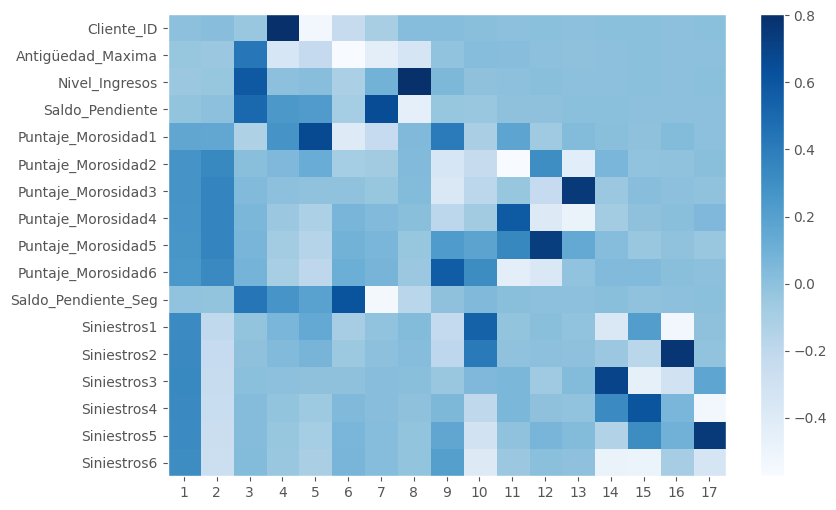

In [82]:
# Heatmap de los 15 componentes
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9, 6))
componentes = modelo_pca.components_
plt.imshow(componentes.T, cmap='Blues', aspect='auto') 
plt.yticks(range(len(df3.columns)), df3.columns)
plt.xticks(range(len(df3.columns)), np.arange(modelo_pca.n_components_) + 1)
plt.grid(False)
plt.colorbar();

### Varianza explicada en cada componente

----------------------------------------------------
Porcentaje de varianza explicada por cada componente
----------------------------------------------------
[0.4210169  0.16598819 0.10859089 0.06164096 0.05484036 0.04870374
 0.04237556 0.03122172 0.01797598 0.01580922 0.00989053 0.00764327
 0.00657352 0.00336533 0.00201618 0.00129443 0.00105322]


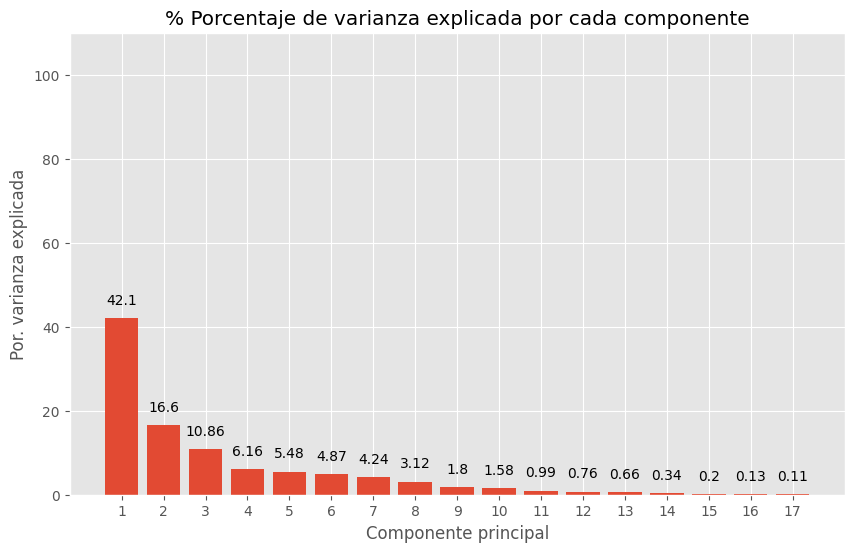

In [83]:
# Porcentaje de varianza explicada por cada componente
# ==============================================================================
print('----------------------------------------------------')
print('Porcentaje de varianza explicada por cada componente')
print('----------------------------------------------------')
print(modelo_pca.explained_variance_ratio_)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
ax.bar(
    x = np.arange(modelo_pca.n_components_) + 1,
    height = modelo_pca.explained_variance_ratio_*100
)

for x, y in zip(np.arange(len(df3.columns)) + 1, modelo_pca.explained_variance_ratio_*100):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_ylim(0, 1.1*100)
ax.set_title('% Porcentaje de varianza explicada por cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada');

De acuerdo al gráfico anterior, las primeras 5 componentes principales son las que se deberían utilizar en el modelo debido a que éstas tienen un porcentaje superior al 5%

### Varianza explicada acumulada

------------------------------------------
Porcentaje de varianza explicada acumulada
------------------------------------------
[0.4210169  0.58700509 0.69559598 0.75723694 0.8120773  0.86078103
 0.9031566  0.93437832 0.9523543  0.96816352 0.97805405 0.98569732
 0.99227084 0.99563617 0.99765235 0.99894678 1.        ]


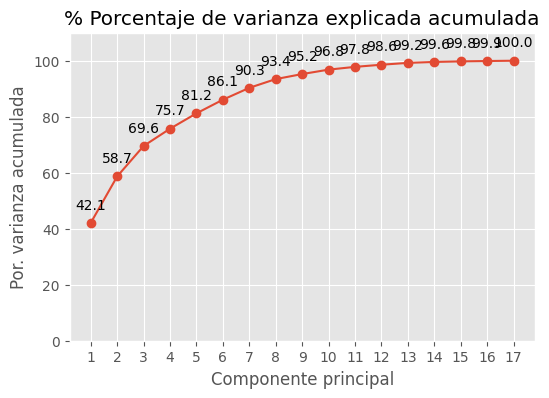

In [84]:
# Porcentaje de varianza explicada acumulada

prop_varianza_acum = modelo_pca.explained_variance_ratio_.cumsum()
print('------------------------------------------')
print('Porcentaje de varianza explicada acumulada')
print('------------------------------------------')
print(prop_varianza_acum)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(
    np.arange(len(df3.columns)) + 1,
    prop_varianza_acum*100,
    marker = 'o'
)

for x, y in zip(np.arange(len(df3.columns)) + 1, prop_varianza_acum*100):
    label = round(y, 1)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )
    
ax.set_ylim(0, 1.1*100)
ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_title('% Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza acumulada');

Según este gráfico acumulado, los 6 primeros componentes representarían al casi 86,1% de las varianzas acumuladas del modelo y serían principalmente esas las que se deberían utilizar.

## Identificar las variables más importantes
Según el modelo PCA, se toma la decisión de incorporar 6 variables principales, con lo cual el modelo quería con un valor de varianzas acumuladas de 86,1%

## Realizar un modelo de segmentación de clientes
### Análisis Cluster
Para este análisis, se utilizará la variable dicotómicas de `Estado_Siniestro` con valores binarios a fin de realizar los análisis de Cluster.


In [85]:
df1 = df1.iloc[:,1:18]

In [86]:
df1.head(3)

,Antigüedad_Maxima,Nivel_Ingresos,Saldo_Pendiente,Puntaje_Morosidad1,Puntaje_Morosidad2,Puntaje_Morosidad3,Puntaje_Morosidad4,Puntaje_Morosidad5,Puntaje_Morosidad6,Saldo_Pendiente_Seg,Siniestros1,Siniestros2,Siniestros3,Siniestros4,Siniestros5,Siniestros6,Estado_Siniestro
0,44.0,1.0,604.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,79.0,1.0,1006.21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,102.0,1.0,299.23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Tratamiento de variables a `int`

In [87]:
# Corregimos la variable Estado_Siniestro =0
df1['Estado_Siniestro'] = df1['Estado_Siniestro'].astype('int')

### Escalamiento de los datos

In [88]:
# Tratamiento de datos

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.datasets import make_blobs

# Gráficos

import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado

from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import scale
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale
from sklearn.metrics import silhouette_score

# Configuración warnings

import warnings
warnings.filterwarnings('ignore')

np.random.seed(12345)

In [89]:
#Visualización del DataFrame compuesto por variables cuantitativas
df1.sample(4)

,Antigüedad_Maxima,Nivel_Ingresos,Saldo_Pendiente,Puntaje_Morosidad1,Puntaje_Morosidad2,Puntaje_Morosidad3,Puntaje_Morosidad4,Puntaje_Morosidad5,Puntaje_Morosidad6,Saldo_Pendiente_Seg,Siniestros1,Siniestros2,Siniestros3,Siniestros4,Siniestros5,Siniestros6,Estado_Siniestro
623,76.000000,1.0,741.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
26,15.000000,1.0,276.72,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1550,55.697884,1.0,1157.18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1513,82.000000,1.0,558.83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [90]:
# Estandarización de las variables
# ==============================================================================
datos_scaled = scale(X=df1, axis=0, with_mean=True, with_std=True) 

datos_scaled = pd.DataFrame(datos_scaled, 
                            columns=df1.columns, 
                            index=df1.index)

datos_scaled.head(4)

,Antigüedad_Maxima,Nivel_Ingresos,Saldo_Pendiente,Puntaje_Morosidad1,Puntaje_Morosidad2,Puntaje_Morosidad3,Puntaje_Morosidad4,Puntaje_Morosidad5,Puntaje_Morosidad6,Saldo_Pendiente_Seg,Siniestros1,Siniestros2,Siniestros3,Siniestros4,Siniestros5,Siniestros6,Estado_Siniestro
0,-0.244487,-0.144691,-0.465830,-0.30117,-0.260336,-0.245476,-0.232086,-0.239073,-0.231647,-0.238267,-0.237704,-0.226882,-0.216876,-0.205044,-0.19651,-0.185404,-0.342186
1,0.528241,-0.144691,-0.404635,-0.30117,-0.260336,-0.245476,-0.232086,-0.239073,-0.231647,-0.238267,-0.237704,-0.226882,-0.216876,-0.205044,-0.19651,-0.185404,-0.342186
2,1.036033,-0.144691,-0.512430,-0.30117,-0.260336,-0.245476,-0.232086,-0.239073,-0.231647,-0.238267,-0.237704,-0.226882,-0.216876,-0.205044,-0.19651,-0.185404,-0.342186
3,0.077524,-0.144691,-0.459681,-0.30117,-0.260336,-0.245476,-0.232086,-0.239073,-0.231647,-0.238267,-0.237704,-0.226882,-0.216876,-0.205044,-0.19651,-0.185404,-0.342186


### Cálculo de distancias euclidianas

In [91]:
# Cálculo de distancias

print('------------------')
print('Distancia euclídea')
print('------------------')
distancias = pairwise_distances(
                X      = datos_scaled,
                metric ='euclidean'
             )

# Se descarta la diagonal superior de la matriz
distancias[np.triu_indices(n=distancias.shape[0])] = np.nan

distancias = pd.DataFrame(
                distancias,
                columns=datos_scaled.index,
                index = datos_scaled.index
            )

distancias.head(8)

------------------
Distancia euclídea
------------------


,0,1,2,3,4,5,6,7,8,9,...,4722,4723,4724,4725,4726,4727,4728,4729,4730,4731
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.775147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.281368,0.519108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.322069,0.454066,0.959960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.463433,0.729299,0.320592,1.149729,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.138012,2.390883,1.902936,2.824105,1.675079,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2.982285,2.252357,1.827531,2.678115,1.857483,1.603420,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.764127,1.621231,1.714401,1.661808,1.794175,2.934672,2.840014,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Se reestructura la Matriz para ordenar de menor a mayor las distancias usando el comando `sort_values`

In [92]:
# Top n registros más similares

distancias.melt(ignore_index=False, var_name="estado_b", value_name='distancia') \
    .rename_axis("estado_a") \
    .reset_index() \
    .dropna() \
    .sort_values('distancia') \
    .head(10)

,estado_a,estado_b,distancia
508327,2003,107,0.000064
11089493,2417,2343,0.000078
14706164,3840,3107,0.000110
20124738,4274,4252,0.000110
13874166,4674,2931,0.000111
1533142,4706,323,0.000114
4946640,1700,1045,0.000166
9570726,2622,2022,0.000198
6631623,2091,1401,0.000244
10465452,3000,2211,0.000252


### Número óptimo de Clusters

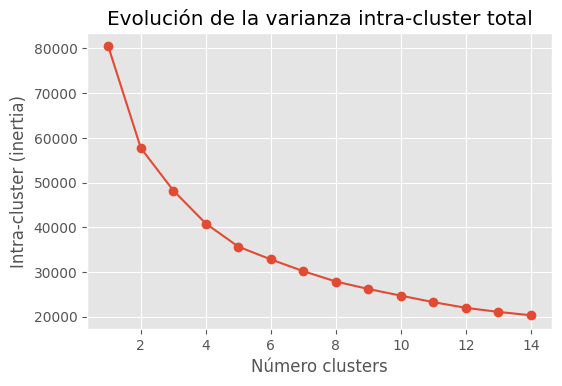

In [93]:
# Método elbow para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(1, 15)
inertias = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
                        n_clusters   = n_clusters, 
                        n_init       = 20, 
                        random_state = 123
                    )
    modelo_kmeans.fit(datos_scaled)
    inertias.append(modelo_kmeans.inertia_)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, inertias, marker='o')
ax.set_title("Evolución de la varianza intra-cluster total")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Intra-cluster (inertia)');

De acuerdo a la gráfica anterior, sería posible concluir que las tasas de decrecimientos visualizadas en el gráfico permiten determinar que la cantidad óptima de cluster pueden ser 5.

## Inclusión de la variable segmento $Cluster_i$ en el modelo final
### Entrenamiento de los datos (k=5)

In [94]:
kmeans = KMeans(n_clusters=5).fit(datos_scaled)
centroids = kmeans.cluster_centers_
print(centroids)

[[ 0.04671739  0.05280012  0.01866476 -0.22996182 -0.19736353 -0.18127844
  -0.1644131  -0.15987637 -0.14144555  0.01878827 -0.17855753 -0.17010746
  -0.15790153 -0.14704026 -0.13942282 -0.12847799 -0.23601542]
 [ 0.082241   -0.32110722 -0.32309501  0.70116469  4.0245739   4.02265823
   3.93919823  3.40619377  3.32936892  0.23094466 10.0202918  10.64922526
  11.17618334 11.70076982 11.79136497 11.76288127  0.80041284]
 [-0.25725959 -0.26112538 -0.14115218  1.59415411  1.11440567  1.06061944
   1.03916269  1.06391627  1.19275919 -0.11682397  3.94300737  3.9477857
   3.80661913  3.52766972  3.35127452  3.1421292   1.31186207]
 [-0.18155201 -0.28374262 -0.20336723  1.00056347  8.34774229  9.100439
   9.1852263   8.90179283  8.55527582 -0.2215879   1.04822893  1.15617314
   1.2127554   1.19376991  1.02914153  0.86420055  1.40669004]
 [-0.52817026 -0.57228762 -0.17024061  2.45151099  1.33051651  1.07454371
   0.86207184  0.85416066  0.62372017 -0.20881704  0.70947191  0.55402389
   0.393713

In [95]:
#Cantidad de cluster generados
kmeans.n_clusters


5

In [96]:
# cluster al que pertenece cada persona
cluster = kmeans.predict(datos_scaled)
cluster

array([0, 0, 0, ..., 0, 3, 4], dtype=int32)

In [97]:
# El cluster en nuestro DataFrame

df3['cluster'] = cluster
df3['cluster'].replace({0: "Clúster 0",  # etiquetamos los grupos
                                   1: "Clúster 1",
                                   2: "Clúster 2",
                                   3: "Clúster 3",
                                   4: "Clúster 4"},
                                  inplace=True)
df3.head()

,Cliente_ID,Antigüedad_Maxima,Nivel_Ingresos,Saldo_Pendiente,Puntaje_Morosidad1,Puntaje_Morosidad2,Puntaje_Morosidad3,Puntaje_Morosidad4,Puntaje_Morosidad5,Puntaje_Morosidad6,Saldo_Pendiente_Seg,Siniestros1,Siniestros2,Siniestros3,Siniestros4,Siniestros5,Siniestros6,cluster
0,185.0,44.000000,1.000000,604.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Clúster 0
1,238.0,79.000000,1.000000,1006.21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Clúster 0
2,346.0,102.000000,1.000000,299.23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Clúster 0
3,460.0,58.585178,1.000000,645.19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Clúster 0
4,549.0,109.000000,1.332853,218.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Clúster 0


In [98]:
# Perfilando cada Estrato. Podemos añadir variables cualitativas para su mejor entendimiento.
#---------------------------------------------------------------------------------------------
df3.groupby(['cluster'])[columns].mean().round(2).T

cluster,Clúster 0,Clúster 1,Clúster 2,Clúster 3,Clúster 4
Cliente_ID,393431.70,343124.85,373600.27,456107.93,395905.39
Antigüedad_Maxima,57.19,58.80,43.42,46.85,31.15
Nivel_Ingresos,1.23,0.79,0.86,0.84,0.49
Saldo_Pendiente,3782.45,1541.00,2734.28,2326.24,2543.50
Puntaje_Morosidad1,0.04,0.55,1.04,0.71,1.51
Puntaje_Morosidad2,0.05,3.20,1.03,6.43,1.19
Puntaje_Morosidad3,0.05,3.05,0.93,6.68,0.94
Puntaje_Morosidad4,0.05,2.80,0.85,6.32,0.73
Puntaje_Morosidad5,0.05,2.35,0.84,5.89,0.70
Puntaje_Morosidad6,0.06,2.20,0.88,5.43,0.53


In [99]:
# Tabla de frecuencia del Cluster
cluster_count = (df3
                       .groupby("cluster")
                       .agg(frequency=("cluster", "count")))

cluster_count["Acumulado"] = cluster_count["frequency"].cumsum()
cluster_count

,frequency,Acumulado
cluster,,
Clúster 0,4274,4274
Clúster 1,20,4294
Clúster 2,75,4369
Clúster 3,28,4397
Clúster 4,335,4732


### Graficando  las variables numérica

In [100]:
import seaborn as sns

def graficar_nums(cluster, var_num, data):

  fig, ax = plt.subplots(figsize=(6, 3.84))

  sns.violinplot(
          x     = cluster,
          y     = var_num,
          data  = data,
          #color = "white",
          ax    = ax
      )

  ax.set_title(f'{var_num} por Cluster');

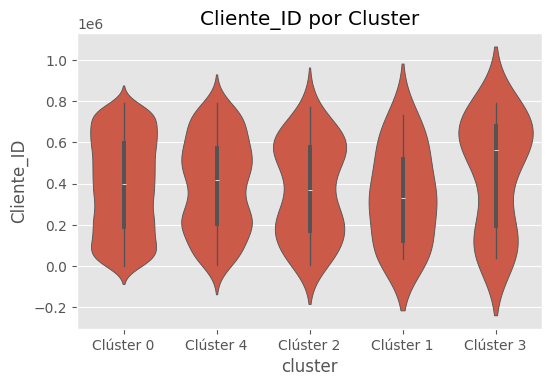

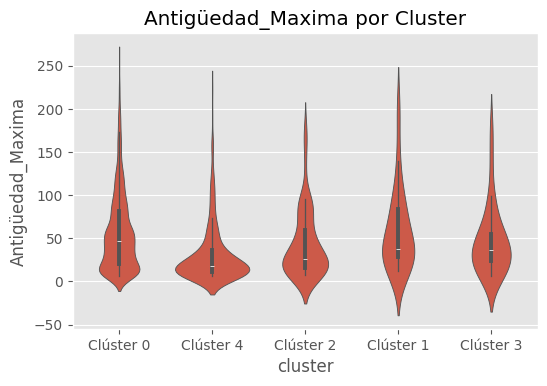

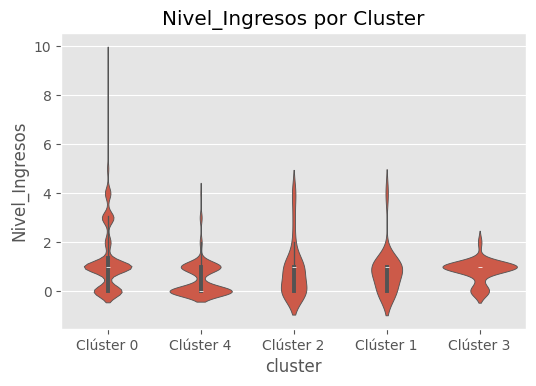

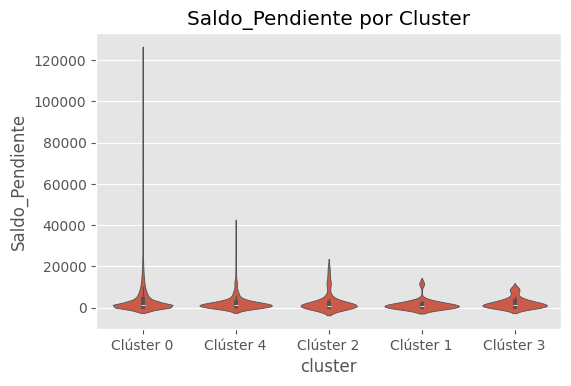

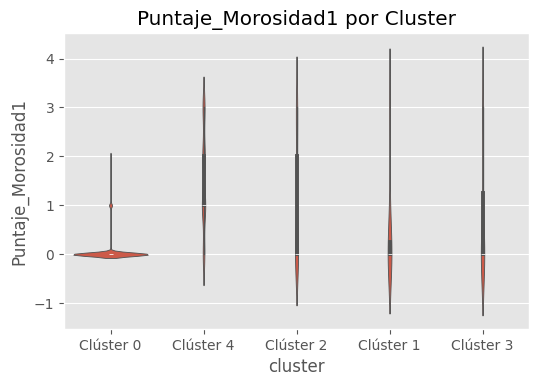

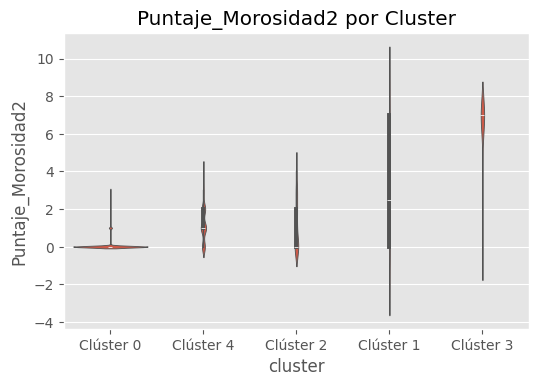

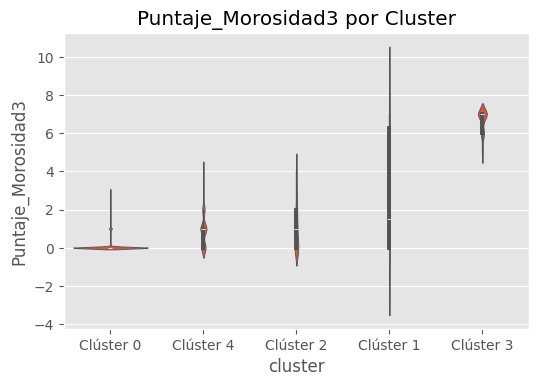

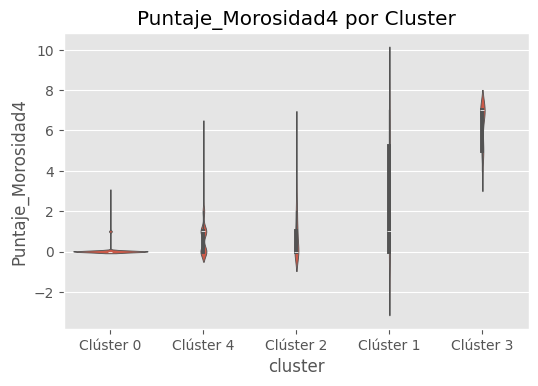

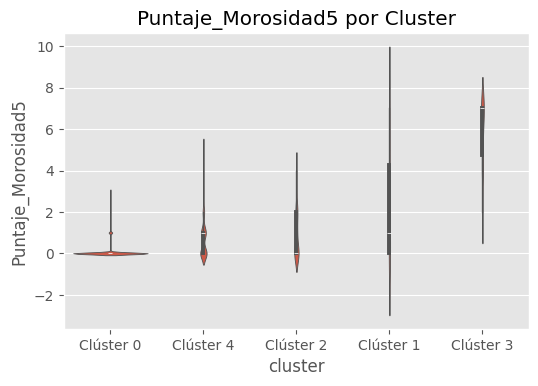

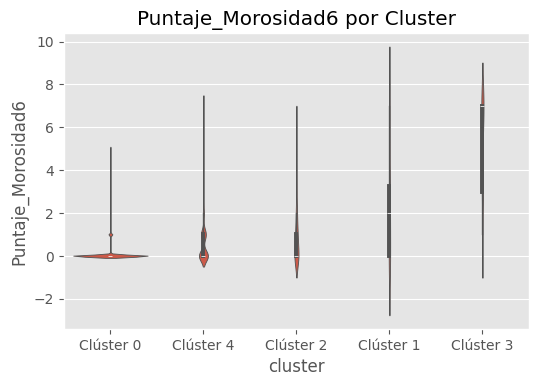

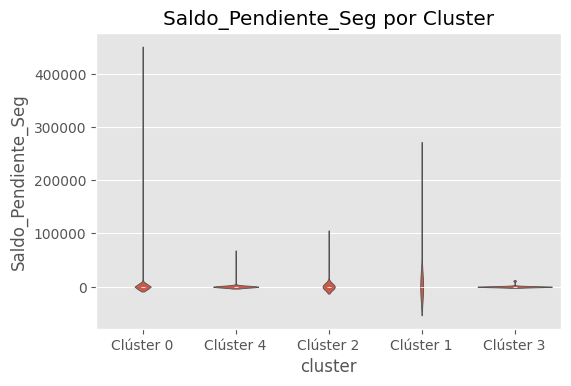

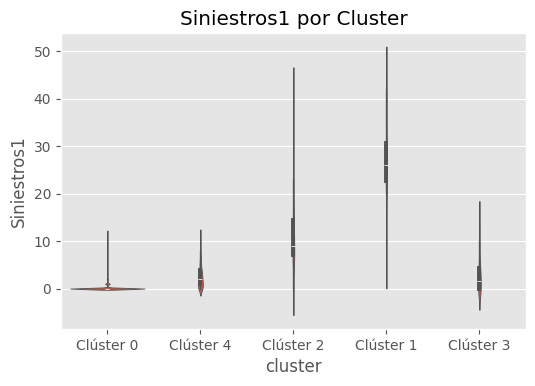

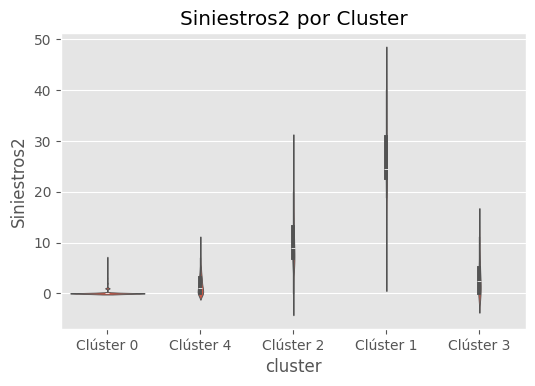

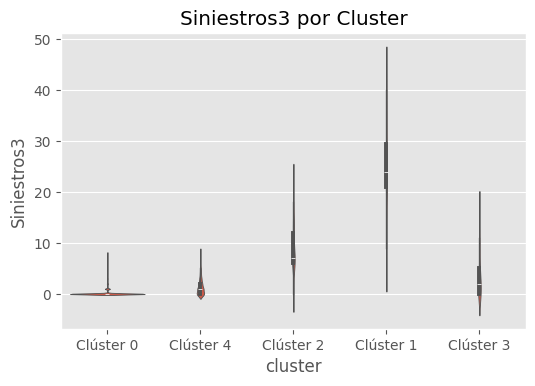

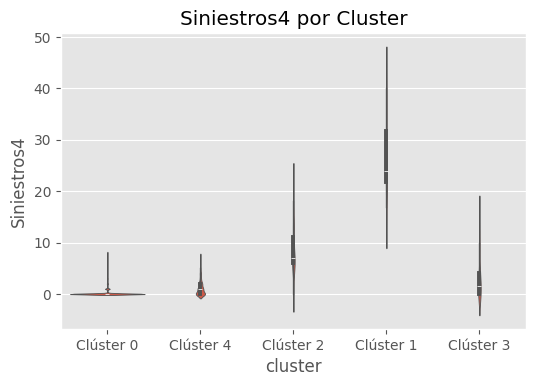

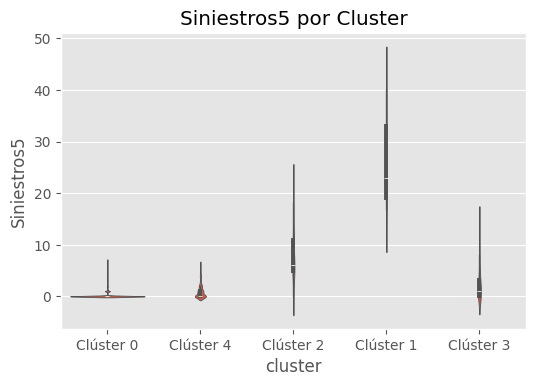

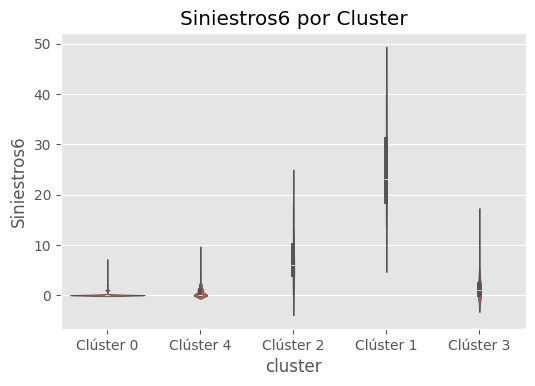

In [101]:
cluster = 'cluster'

for i in columns: 
  graficar_nums(cluster, i, df3)

-------------------------------------------
Documento elaborado por Osvaldo Cubillos